# Avance1.8 · Análisis exploratorio de PTB-XL 1.0.3

Equipo 8 · Cardio AI

**Objetivo:** caracterizar estructura, distribuciones, relaciones y calidad de ECG de 12 derivaciones,
y ejecutar un preprocesamiento trazable para una tarea **multietiqueta**. No se entrena un clasificador.

PTB-XL es un **sustituto público para desarrollar el procedimiento**, no el dataset italiano del proyecto.
Sus prevalencias, edades y problemas describen PTB-XL y no el conjunto del sponsor.

El análisis describe todos los metadatos y las señales de 500 Hz. Cada sección presenta una pregunta,
su evidencia estadística y gráfica, y su interpretación. Las conclusiones se calculan al final a partir
de los resultados de la ejecución. Las cinco superclases son anotaciones diagnósticas del dataset;
no constituyen una definición validada de cribado en estudiantes.

### Fuente y convenciones del dataset

- [PTB-XL 1.0.3, PhysioNet](https://physionet.org/content/ptb-xl/1.0.3/), Wagner et al. (2022),
  [DOI del dataset](https://doi.org/10.13026/kfzx-aw45), licencia CC BY 4.0.
- Wagner et al. (2020), [publicación original](https://doi.org/10.1038/s41597-020-0495-6).
- Documentación de funciones: [WFDB](https://wfdb.readthedocs.io/),
  [NeuroKit2](https://neuropsychology.github.io/NeuroKit/),
  [SciPy](https://docs.scipy.org/doc/scipy/).
- Las edades de mayores de 89 años están codificadas para privacidad: no son edades exactas de 300 ni 90.
- Las fechas están desplazadas por paciente: no permiten fechar cambios institucionales reales.
- SCP con valor 0 significa verosimilitud no especificada, no ausencia de la afirmación.
- Se preservan los folds oficiales; nunca se mezclan pacientes entre particiones.

### Trazabilidad de la fusión

Las celdas de origen están numeradas desde 1, incluyendo Markdown. **Adaptado** no significa copiado
literalmente. La lectura y las medidas de señales están en `ecg_experiment/eda/avance1_fusion.py`;
las asociaciones categóricas reutilizan `ecg_experiment/eda/profile.py`. La tabla identifica
las secciones adaptadas de cada notebook, no equivalencias entre todos sus algoritmos.

| Sección final | Origen | Tratamiento |
|---|---|---|
| 1. Estructura y diccionario | `01-jr-ptbxl`, c. 5–12; `EDA_PTB-XL`, c. 5 | Adaptación; perfil de todas las columnas y frecuencias completas |
| 2. Etiquetas, coocurrencia y desequilibrio | `EDA_PTB-XL`, c. 7–10; `01-jr-ptbxl`, c. 37–43, 54 | Código adaptado; objetivo multietiqueta, sin heredar etiqueta binaria como principal |
| 3. Faltantes y cardinalidad | Ambos, secciones de faltantes; `01-jr-ptbxl`, c. 18–20 | Adaptación; separar ausencia de anotación de ausencia clínica |
| 4. Atípicos y limpieza tabular | `01-jr-ptbxl`, c. 22, 46–50; `EDA_PTB-XL`, c. 26, 56 | Reimplementación con bitácora, originales preservados y parámetros ajustados en entrenamiento |
| 5. Calidad y medidas de señales | `01-jr-ptbxl`, c. 63–70; `EDA_PTB-XL`, c. 12–13 | Reimplementación: WFDB, unidades, canales, NaN, segmentos planos, amplitud, residuales y HR |
| 6. Univariante y asimetría | `01-jr-ptbxl`, c. 25–29; `EDA_PTB-XL`, c. 39–40 | Adaptación: histogramas/boxplots y transformaciones que no borran los originales |
| 7. Relaciones, categorías y tiempo | `01-jr-ptbxl`, c. 52–59; `EDA_PTB-XL`, c. 43, 46, 49 | Adaptación: Spearman, Cramér V, denominadores, una observación por paciente como sensibilidad |
| 8. Señales y escalamiento | `01-jr-ptbxl`, c. 73, 76, 79; `EDA_PTB-XL`, c. 52–54 | Adaptación: mV originales, sin imponer filtrado ni z-score clínicamente |
| 9. Preparación, exportación y conclusiones | `EDA_PTB-XL`, c. 55–58; `01-jr-ptbxl`, c. 81–82 | Integración nueva: conclusiones calculadas, límites y validaciones de alineación |

## 0. Configuración y ejecución

La ejecución utiliza Python 3.11 y los datos locales en `data/raw/ptb-xl/1.0.3/`.
La ruta se detecta desde la raíz del repositorio o cualquiera de sus subdirectorios.
`PTBXL_DIR` permite indicar otra ubicación del mismo dataset. No se realizan descargas.
Las tablas de salida se guardan en `outputs/eda/avance1_fusion/full/`.

Comando desde la raíz del repositorio:

```bash
uv run --no-sync --with neurokit2==0.2.13 python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=7200 notebooks/Avance1.8.ipynb
```

NeuroKit2 se usa en un entorno temporal de `uv`, porque su dependencia de pandas difiere de
la versión fijada por el proyecto. Este comando conserva `.venv`, `pyproject.toml` y `uv.lock`.
El manifiesto final registra las versiones efectivamente utilizadas.


In [1]:
from pathlib import Path
import os, sys, ast, json, hashlib, platform
from datetime import datetime, timezone
from functools import partial
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps, stats
from sklearn.preprocessing import PowerTransformer
import wfdb
from tqdm.auto import tqdm
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
sys.path.insert(0, str(ROOT))
from ecg_experiment.eda.avance1_fusion import read_dataset_ecg, extract_signal_features
from ecg_experiment.eda.profile import cramers_v
from ecg_experiment.paths import to_stored

SIGNAL_MODE = os.environ.get("PTBXL_SIGNAL_MODE", "full")
SAMPLE_SIZE, SEED, FS = 128, 8, 500
DATA_DIR = Path(os.environ.get("PTBXL_DIR", ROOT / "data/raw/ptb-xl/1.0.3"))
OUT = Path(os.environ.get("PTBXL_EDA_OUT", ROOT / "outputs/eda/avance1_fusion" / SIGNAL_MODE))
OUT.mkdir(parents=True, exist_ok=True)
RUN_STARTED = datetime.now(timezone.utc).isoformat()
BASE_URL = "https://physionet.org/files/ptb-xl/1.0.3/"
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
QUALITY = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems", "extra_beats", "pacemaker"]
assert SIGNAL_MODE in {"sample", "full"}
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})
pd.set_option("display.max_columns", 30)

versions = {p: version(p) for p in ["numpy", "pandas", "scipy", "matplotlib", "seaborn", "scikit-learn", "wfdb", "neurokit2"]}
print("Python:", platform.python_version(), "| modo de señales:", SIGNAL_MODE, "| Hz:", FS)
display(pd.Series(versions, name="version"))
print("Datos:", DATA_DIR)
print("Resultados:", OUT)


/home/janetrivera/ecg-cardiopathy-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.13 | modo de señales: full | Hz: 500


numpy            2.4.6
pandas           2.3.3
scipy           1.17.1
matplotlib      3.11.2
seaborn         0.13.2
scikit-learn     1.9.1
wfdb             4.3.1
neurokit2       0.2.13
Name: version, dtype: object

Datos: /home/janetrivera/ecg-cardiopathy-detection/data/raw/ptb-xl/1.0.3
Resultados: /home/janetrivera/ecg-cardiopathy-detection/outputs/eda/avance1_fusion/full


## 1. Estructura, tipos y estadística descriptiva

Una fila de metadatos representa un ECG, no una muestra de voltaje ni necesariamente una persona distinta.
Los códigos numéricos de sitio/enfermería son nominales. Los identificadores y el texto libre se describen
con conteos, cardinalidad y longitud, no con medias sin significado.

In [2]:
metadata_path = DATA_DIR / "ptbxl_database.csv"
statements_path = DATA_DIR / "scp_statements.csv"
raw = pd.read_csv(metadata_path, index_col="ecg_id")
scp = pd.read_csv(statements_path, index_col=0)
assert raw.strat_fold.isin(range(1,11)).all(), "Fold fuera de 1–10"
assert raw.index.is_unique, "ecg_id duplicados; revisar antes de continuar"
assert raw.patient_id.notna().all(), "No se puede verificar partición sin patient_id"
meta = raw.copy(deep=True)
meta["scp_codes"] = meta["scp_codes"].map(ast.literal_eval)
assert meta.scp_codes.map(lambda x: isinstance(x, dict)).all()
meta["recording_date"] = pd.to_datetime(meta.recording_date, errors="raise")
for col in ["patient_id", "nurse", "site", "validated_by"]:
    meta[col] = meta[col].astype("Int64")
units = {"age": "años (valores >=300 censurados)", "height": "cm", "weight": "kg"}
ids = {"patient_id", "filename_lr", "filename_hr"}
annotations = set(QUALITY + ["report", "scp_codes"])
def scale(col):
    if col in units: return "cuantitativa"
    if col in ids: return "identificador"
    if col == "recording_date": return "temporal anonimizada"
    if col in annotations: return "texto / anotación estructurada"
    if col.startswith("infarction_stadium"): return "categórica: estadios ordenados y estados no ordenables"
    return "categórica nominal"
profile = pd.DataFrame({"dtype": raw.dtypes.astype(str), "escala": [scale(c) for c in raw],
                        "unidad": [units.get(c, "no aplica") for c in raw],
                        "presentes": raw.notna().sum(), "faltantes_n": raw.isna().sum(),
                        "faltantes_pct": raw.isna().mean()*100, "cardinalidad": raw.nunique()})
display(profile)
display(raw[["age", "height", "weight"]].describe().T)
display(raw.select_dtypes(exclude="number").describe().T)
cat_cols = [c for c in raw if scale(c).startswith(("categórica", "ordinal"))]
frequency_tables = {c: raw[c].astype("string").fillna("NO_ANOTADO").value_counts(dropna=False).rename("n").to_frame() for c in cat_cols}
for c, table in frequency_tables.items():
    table["porcentaje"] = 100*table.n/len(raw)
frequency_all = pd.concat(frequency_tables, names=["variable", "valor"])
with pd.option_context("display.max_rows", 250):
    display(frequency_all)
display(raw[["report", *QUALITY]].fillna("").astype(str).apply(lambda c: c.str.len()).describe().T)
patient_counts = meta.groupby("patient_id").size()
display(patient_counts.value_counts().sort_index().to_frame("pacientes_por_numero_de_ECG"))
print(f"ECG: {len(meta):,}; pacientes: {meta.patient_id.nunique():,}; columnas originales sin índice: {raw.shape[1]}")
print("Pacientes en más de un fold:", meta.groupby("patient_id").strat_fold.nunique().gt(1).sum())
assert meta.groupby("patient_id").strat_fold.nunique().max() == 1
profile.to_csv(OUT / "perfil_columnas.csv")
frequency_all.to_csv(OUT / "frecuencias_completas.csv")

,dtype,escala,unidad,presentes,faltantes_n,faltantes_pct,cardinalidad
patient_id,float64,identificador,no aplica,21799,0,0.000000,18869
age,float64,cuantitativa,años (valores >=300 censurados),21799,0,0.000000,89
sex,int64,categórica nominal,no aplica,21799,0,0.000000,2
height,float64,cuantitativa,cm,6974,14825,68.007707,77
weight,float64,cuantitativa,kg,9421,12378,56.782421,127
nurse,float64,categórica nominal,no aplica,20326,1473,6.757191,12
site,float64,categórica nominal,no aplica,21782,17,0.077985,51
device,object,categórica nominal,no aplica,21799,0,0.000000,11
recording_date,object,temporal anonimizada,no aplica,21799,0,0.000000,21795
report,object,texto / anotación estructurada,no aplica,21799,0,0.000000,9887


,count,mean,std,min,25%,50%,75%,max
age,21799.0,62.769301,32.308813,2.0,50.0,62.0,72.0,300.0
height,6974.0,166.702323,10.867321,6.0,160.0,166.0,174.0,209.0
weight,9421.0,70.995223,15.878803,5.0,60.0,70.0,80.0,250.0


,count,unique,top,freq
device,21799,11,CS100 3,6140
recording_date,21799,21795,2000-08-08 09:34:05,2
report,21799,9887,sinus rhythm. normal ecg.,1734
scp_codes,21799,5463,"{'NORM': 100.0, 'SR': 0.0}",6142
heart_axis,13331,8,MID,7687
infarction_stadium1,5612,6,unknown,3430
infarction_stadium2,103,3,Stadium III,65
second_opinion,21799,2,False,21244
initial_autogenerated_report,21799,2,False,14986
validated_by_human,21799,2,True,16056


n  porcentaje
variable                     valor                            
sex                          0               11354   52.084958
                             1               10445   47.915042
nurse                        0.0              8295   38.052204
                             1.0              5709   26.189275
                             NO_ANOTADO       1473    6.757191
                             5.0               648    2.972613
                             3.0               642    2.945089
                             7.0               639    2.931327
                             2.0               639    2.931327
                             4.0               635    2.912978
                             6.0               631    2.894628
                             8.0               626    2.871691
                             10.0              626    2.871691
                             11.0              619     2.83958
                             9.0               617    2.830405
site                         0.0              8940   41.011056
                             1.0              6294   28.872884
                             2.0              5075   23.280884
                             3.0               576    2.642323
                             4.0               100    0.458737
                             5.0                58    0.266067
                             6.0                46    0.211019
                             8.0                43    0.197257
                             7.0                43    0.197257
                             9.0                38     0.17432
                             10.0               37    0.169733
                             11.0               33    0.151383
                             14.0               26    0.119272
                             12.0               26    0.119272
                             15.0               25    0.114684
                             13.0               24    0.110097
                             16.0               22    0.100922
                             17.0               20    0.091747
                             21.0               18    0.082573
                             20.0               18    0.082573
                             NO_ANOTADO         17    0.077985
                             18.0               17    0.077985
                             22.0               15     0.06881
                             28.0               15     0.06881
                             27.0               15     0.06881
                             19.0               15     0.06881
                             26.0               15     0.06881
                             23.0               15     0.06881
                             29.0               15     0.06881
                             24.0               14    0.064223
                             25.0               13    0.059636
                             31.0               13    0.059636
                             32.0               13    0.059636
                             34.0               12    0.055048
                             30.0               12    0.055048
                             36.0               12    0.055048
                             35.0               11    0.050461
                             37.0               10    0.045874
                             33.0               10    0.045874
                             38.0               10    0.045874
                             40.0                9    0.041286
                             41.0                9    0.041286
                             39.0                8    0.036699
                             44.0                7    0.032112
                             45.0                6    0.027524
                             42.0                6    0.027524
                             43.0                6    0.027524
                 

,count,mean,std,min,25%,50%,75%,max
report,21799.0,106.108354,66.158365,1.0,44.0,93.0,148.0,397.0
baseline_drift,21799.0,0.541172,2.072110,0.0,0.0,0.0,0.0,23.0
static_noise,21799.0,1.683151,4.088998,0.0,0.0,0.0,0.0,27.0
burst_noise,21799.0,0.116703,0.760380,0.0,0.0,0.0,0.0,16.0
electrodes_problems,21799.0,0.006055,0.257665,0.0,0.0,0.0,0.0,24.0
extra_beats,21799.0,0.452223,1.701184,0.0,0.0,0.0,0.0,17.0
pacemaker,21799.0,0.172393,1.484516,0.0,0.0,0.0,0.0,13.0


,pacientes_por_numero_de_ECG
1,16758
2,1590
3,350
4,99
5,43
6,16
7,5
8,4
9,3
10,1


ECG: 21,799; pacientes: 18,869; columnas originales sin índice: 27
Pacientes en más de un fold: 0


**Lectura:** el resumen incluye todas las columnas con estadísticas apropiadas a su escala.
El tamaño efectivo para inferencia por persona es menor que el número de ECG. Los folds son nominales:
los registros se distribuyen en 1–8 para entrenamiento, 9 para validación y 10 para prueba según la fuente.

## 2. Objetivo multietiqueta y desequilibrio

Solo las afirmaciones **diagnósticas** se agregan en cinco superclases. Las de ritmo y forma permanecen
en `scp_codes`; no desaparecen ni equivalen a normalidad. La presencia se define por la clave SCP,
incluyendo verosimilitud 0 (no especificada). Esta es una convención operativa, no certeza clínica.

,ECG,porcentaje_de_todos_los_ECG
NORM,9514,43.644204
MI,5469,25.088307
STTC,5235,24.014863
CD,4898,22.468921
HYP,2649,12.151934


,ECG
n_superclasses,
0,411
1,16244
2,4068
3,919
4,157


Sin superclase diagnóstica: 411
NORM junto a otra superclase: 445
Razón de frecuencia mayor/menor: 3.592


,afirmaciones
0.0,28992
10.0,1
14.0,1
15.0,1752
30.0,1
34.0,1
35.0,417
50.0,3246
80.0,2222
100.0,24374


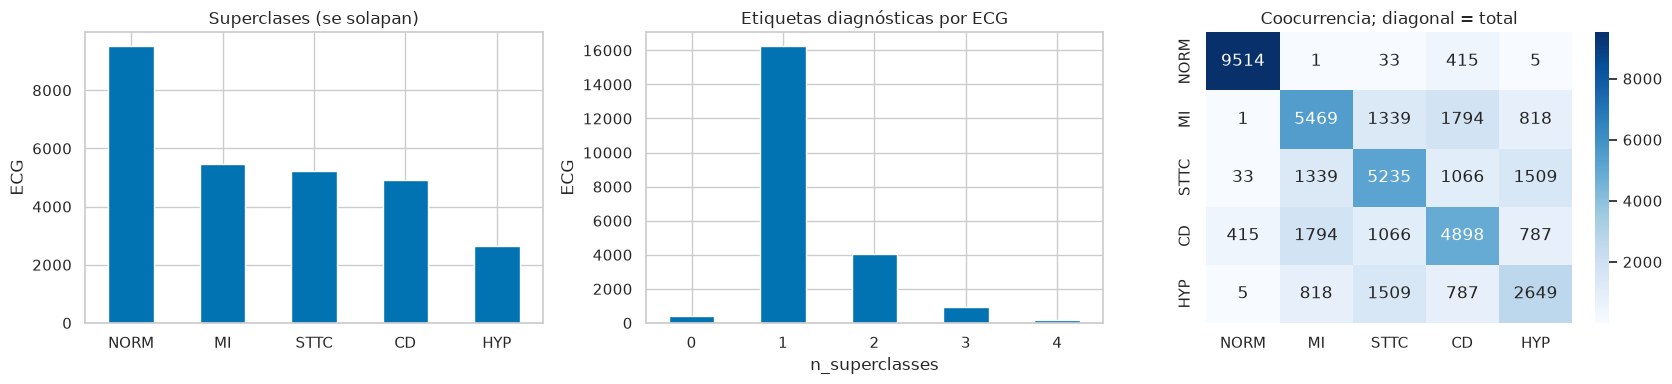

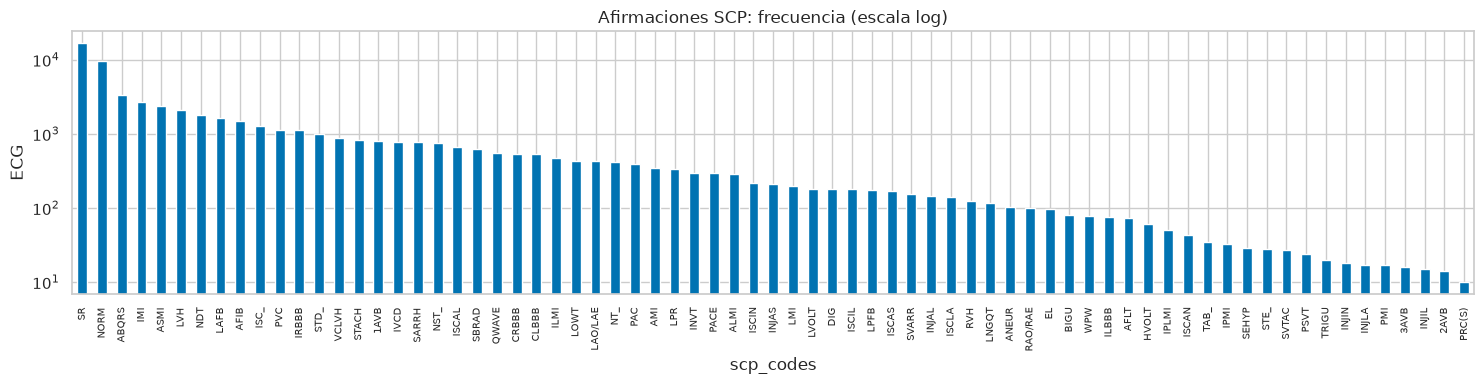

In [3]:
diag = scp.loc[scp.diagnostic.eq(1)]
def to_superclasses(codes):
    return sorted({diag.at[c, "diagnostic_class"] for c in codes if c in diag.index and pd.notna(diag.at[c, "diagnostic_class"])})
meta["superclasses"] = meta.scp_codes.map(to_superclasses)
Y = pd.DataFrame({sc: meta.superclasses.map(lambda cs, sc=sc: int(sc in cs)) for sc in SUPERCLASSES}, index=meta.index)
meta["n_superclasses"] = Y.sum(axis=1)
meta["no_diagnostic_label"] = meta.n_superclasses.eq(0)
meta["norm_with_other_diagnosis"] = Y.NORM.eq(1) & Y.drop(columns="NORM").any(axis=1)
meta["n_statements"] = meta.scp_codes.map(len)
prev = pd.DataFrame({"ECG": Y.sum(), "porcentaje_de_todos_los_ECG": Y.mean()*100})
display(prev)
display(meta.n_superclasses.value_counts().sort_index().to_frame("ECG"))
print("Sin superclase diagnóstica:", meta.no_diagnostic_label.sum())
print("NORM junto a otra superclase:", meta.norm_with_other_diagnosis.sum())
print("Razón de frecuencia mayor/menor:", round(prev.ECG.max()/prev.ECG.min(), 3))
code_counts = meta.scp_codes.map(list).explode().value_counts()
likelihoods = pd.Series([v for d in meta.scp_codes for v in d.values()])
display(likelihoods.value_counts().sort_index().to_frame("afirmaciones"))
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
prev.ECG.plot.bar(ax=axes[0], rot=0, title="Superclases (se solapan)", ylabel="ECG")
meta.n_superclasses.value_counts().sort_index().plot.bar(ax=axes[1], rot=0, title="Etiquetas diagnósticas por ECG", ylabel="ECG")
sns.heatmap(Y.T @ Y, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Coocurrencia; diagonal = total")
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(15, 4))
code_counts.plot.bar(ax=ax, logy=True, title="Afirmaciones SCP: frecuencia (escala log)", ylabel="ECG")
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout(); plt.show()

**Tratamiento:** se conservan las etiquetas originales y todos los registros en el inventario.
`no_diagnostic_label` excluye registros únicamente del subconjunto supervisado de cinco superclases;
no del dataset general ni de los resúmenes generales.
`norm_with_other_diagnosis` es una bandera de revisión semántica, no una prueba automática de error.
El análisis conserva el objetivo multietiqueta y no redefine las etiquetas como cribado binario.

## 3. Faltantes, patrones y alta cardinalidad

Un vacío en calidad significa **sin anotación disponible de ese problema**; no garantiza señal perfecta.
Un estadio de infarto vacío no permite concluir por sí solo que no hay infarto. No se rellena con la
etiqueta objetivo. Las asociaciones de ausencia con dispositivo/diagnóstico son descriptivas: no prueban
que el mecanismo sea MAR o MNAR ni identifican su causa.

,porcentaje_sin_valor
electrodes_problems,99.862379
infarction_stadium2,99.527501
pacemaker,98.665076
burst_noise,97.187944
baseline_drift,92.669389
extra_beats,91.059223
static_noise,85.045186
infarction_stadium1,74.255700
height,68.007707
weight,56.782421


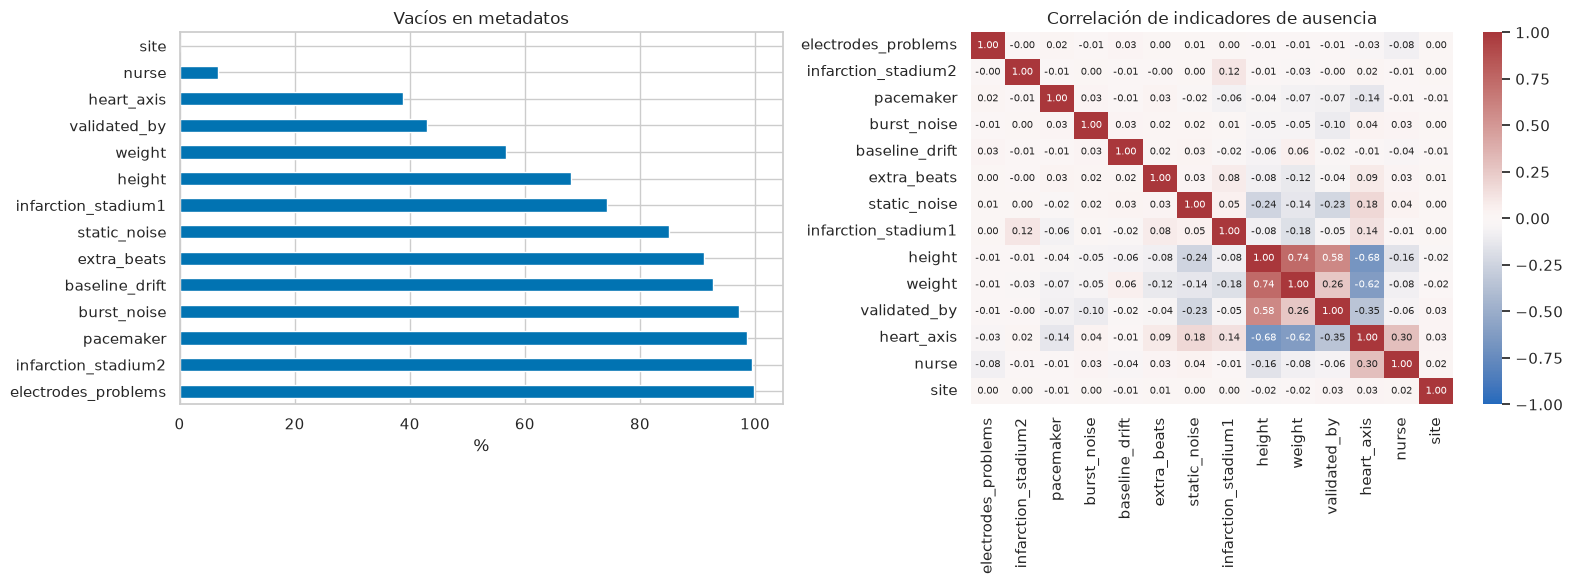

,height,weight,heart_axis,validated_by,nurse
device,,,,,
AT-6 6,6.42,8.84,89.18,0.00,15.71
AT-6 C,100.00,100.00,100.00,81.13,100.00
AT-6 C 5.0,56.25,56.25,93.75,46.25,13.75
AT-6 C 5.3,0.00,0.00,89.55,0.00,16.42
AT-6 C 5.5,5.62,8.38,88.61,0.28,9.80
AT-6 C 5.6,1.69,8.47,91.53,0.00,0.00
AT-6 C 5.8,4.25,4.25,86.29,0.24,15.53
AT-60 3,96.17,96.38,1.45,0.00,0.00
CS-12,98.37,98.47,3.53,0.00,0.02


infarction_stadium1,False,True
MI,,
0,0.875689,99.124311
1,100.000000,0.000000


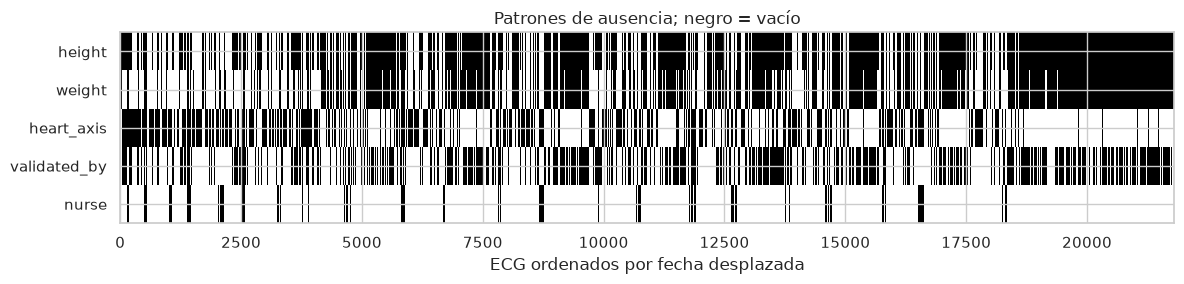

,cardinalidad,faltantes_pct
report,9887,0.000000
site,51,0.077985
validated_by,12,43.020322
baseline_drift,317,92.669389
static_noise,124,85.045186
burst_noise,103,97.187944
electrodes_problems,14,99.862379
extra_beats,128,91.059223
pacemaker,4,98.665076


In [4]:
missing = raw.isna().mean().sort_values(ascending=False)*100
display(missing.to_frame("porcentaje_sin_valor"))
gap_cols = missing.index[missing.gt(0)].tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
missing[missing.gt(0)].plot.barh(ax=axes[0], xlabel="%", title="Vacíos en metadatos")
sns.heatmap(raw[gap_cols].isna().astype(int).corr(), vmin=-1, vmax=1, center=0,
            cmap="vlag", annot=True, fmt=".2f", annot_kws={"size":7}, ax=axes[1])
axes[1].set_title("Correlación de indicadores de ausencia")
plt.tight_layout(); plt.show()
tracked = ["height", "weight", "heart_axis", "validated_by", "nurse"]
display(raw.groupby("device")[tracked].apply(lambda d: d.isna().mean()*100).round(2))
display(pd.crosstab(Y.MI, raw.infarction_stadium1.isna(), normalize="index")*100)
fig, ax = plt.subplots(figsize=(12, 3))
ordered_gaps = meta.sort_values("recording_date")[tracked].isna().astype(int)
ax.imshow(ordered_gaps.T, aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_yticks(range(len(tracked)), tracked)
ax.set(xlabel="ECG ordenados por fecha desplazada", title="Patrones de ausencia; negro = vacío")
plt.tight_layout(); plt.show()
display(profile.loc[["report", "site", "validated_by", *QUALITY], ["cardinalidad", "faltantes_pct"]])

## 4. Atípicos y limpieza reversible de metadatos

Se distingue censura por privacidad, valores sospechosos y atípicos estadísticos. Los umbrales de talla
adulta <100 cm y peso adulto <30 kg son reglas operativas de este EDA. Los valores se excluyen de
las columnas numéricas derivadas mediante `NaN`; el registro y su valor original se conservan.
Esta operación no demuestra que el valor original sea erróneo. Las amplitudes y HR extremos se marcan,
sin eliminarlos únicamente por su magnitud.


In [5]:
clean = meta.copy(deep=True)
clean["age_90plus"] = clean.age.ge(300)
clean["age_numeric"] = clean.age.mask(clean.age_90plus)
clean["age_band"] = pd.cut(clean.age_numeric, [0,18,30,45,60,75,np.inf], right=False,
    labels=["0–17", "18–29", "30–44", "45–59", "60–74", "75–89"]).astype("object")
clean.loc[clean.age_90plus, "age_band"] = "90+ (censurada)"
assert clean.loc[~clean.age_90plus, "age"].between(0, 90, inclusive="left").all()
adult = clean.age_numeric.ge(18) | clean.age_90plus
actions = []
def log_action(field, operation, count, reason):
    actions.append({"campo": field, "operacion": operation, "n": int(count), "justificacion": reason})
log_action("age", "age_numeric=NaN + age_90plus; se conserva age", clean.age_90plus.sum(), "Edad exacta censurada por privacidad")
for col, cutoff in [("height",100), ("weight",30)]:
    flag = adult & clean[col].lt(cutoff)
    clean[f"{col}_suspect"] = flag
    clean[f"{col}_observed"] = clean[col].mask(flag)
    log_action(col, "Cuarentena solo de valor derivado; original intacto", flag.sum(), "Umbral operativo; valor derivado excluido, original conservado")
clean["bmi_observed"] = clean.weight_observed / (clean.height_observed / 100)**2
for col in QUALITY:
    clean[f"annotated_{col}"] = clean[col].notna() & clean[col].astype("string").str.strip().ne("")
for col in ["heart_axis", "infarction_stadium1", "infarction_stadium2", "site", "nurse", "validated_by"]:
    clean[f"{col}_category"] = clean[col].astype("string").fillna("NO_ANOTADO")
clean["device_normalized"] = clean.device.str.split().str.join(" ")
clean["split"] = np.select([clean.strat_fold.le(8), clean.strat_fold.eq(9)], ["train", "validation"], default="test")
for left,right in [("train","validation"),("train","test"),("validation","test")]:
    assert set(clean.loc[clean.split.eq(left),"patient_id"]).isdisjoint(set(clean.loc[clean.split.eq(right),"patient_id"]))
train_mask = clean.split.eq("train")
counts_train = clean.loc[train_mask, "site_category"].value_counts()
kept_sites = counts_train.index[(counts_train >= 30) | (counts_train.index == "NO_ANOTADO")].tolist()
clean["site_grouped"] = clean.site_category.where(clean.site_category.isin(kept_sites), "OTROS")
log_action("site", "Agrupar <30 registros en entrenamiento", clean.site_grouped.ne(clean.site_category).sum(), "Regla aprendida solo con folds 1–8")
log_action("report/scp_codes", "Conservar para trazabilidad; excluir de predictores", len(clean), "Texto diagnóstico produciría fuga de etiqueta")
display(pd.DataFrame(actions))
display(clean.loc[clean.height_suspect | clean.weight_suspect, ["age", "height", "weight", "height_suspect", "weight_suspect"]])
display(clean[["age_numeric", "height_observed", "weight_observed", "bmi_observed"]].describe().T)
display(pd.DataFrame({"cardinalidad_original": [raw.site.nunique(),raw.report.nunique()],
                      "cardinalidad_copia_agrupada": [clean.site_grouped.nunique(),np.nan]},index=["site","report (no categorizado)"]))

,campo,operacion,n,justificacion
0,age,age_numeric=NaN + age_90plus; se conserva age,293,Edad exacta censurada por privacidad
1,height,Cuarentena solo de valor derivado; original in...,9,"Umbral operativo; valor derivado excluido, ori..."
2,weight,Cuarentena solo de valor derivado; original in...,3,"Umbral operativo; valor derivado excluido, ori..."
3,site,Agrupar <30 registros en entrenamiento,574,Regla aprendida solo con folds 1–8
4,report/scp_codes,Conservar para trazabilidad; excluir de predic...,21799,Texto diagnóstico produciría fuga de etiqueta


,age,height,weight,height_suspect,weight_suspect
ecg_id,,,,,
4695,82.0,175.0,17.0,False,True
6059,63.0,173.0,5.0,False,True
6266,60.0,66.0,NaN,True,False
6430,46.0,67.0,NaN,True,False
6481,76.0,80.0,NaN,True,False
7945,77.0,165.0,5.0,False,True
9317,64.0,6.0,NaN,True,False
9384,79.0,6.0,NaN,True,False
15207,86.0,6.0,NaN,True,False


,count,mean,std,min,25%,50%,75%,max
age_numeric,21506.0,59.537245,16.758773,2.000000,50.0000,61.000000,72.000000,89.000000
height_observed,6965.0,166.845370,10.033591,85.000000,160.0000,166.000000,174.000000,209.000000
weight_observed,9418.0,71.014971,15.842403,12.000000,60.0000,70.000000,80.000000,250.000000
bmi_observed,6745.0,25.224963,4.625533,7.653061,22.0741,24.772097,27.748873,59.416025


,cardinalidad_original,cardinalidad_copia_agrupada
site,51,12.0
report (no categorizado),9887,NaN


## 5. Integridad de señales y características derivadas

Lectura registro a registro: no se carga un tensor de varios GB. Se comprueban forma, frecuencia,
unidades **del encabezado**, nombres y orden de canales. No se deducen unidades por la apariencia.
Se miden NaN/infinitos, canales constantes, tramos idénticos ≥1 s, picos >10 mV y residuales de
identidades de derivaciones de extremidades. Son controles técnicos, no diagnósticos. Satisfacer
identidades algebraicas **no demuestra** colocación correcta de electrodos.

HR y dispersión RR son estimaciones de NeuroKit2 en derivación II sobre 10 s; no son mediciones
validadas ni un análisis clínico de variabilidad cardiaca. Se conservan mensajes de fallos/advertencias.
Fracciones de potencia <0.7 Hz y >40 Hz son descriptores operativos dependientes del muestreo y
preprocesamiento, no índices de ruido clínicamente validados.

In [6]:
sample_ids = meta.sample(n=min(SAMPLE_SIZE,len(meta)), random_state=SEED).index.tolist()
analysis_ids = meta.index.tolist() if SIGNAL_MODE == "full" else sample_ids
case_ids = [i for i in [1,12722,10565] if i in meta.index]
for sc in SUPERCLASSES:
    eligible = meta.index[meta.superclasses.map(lambda cs: cs == [sc])]
    if len(eligible): case_ids.append(int(eligible[0]))
all_signal_ids = sorted(set(analysis_ids + case_ids))

read_ecg = partial(read_dataset_ecg, DATA_DIR, meta)
signal_features = partial(extract_signal_features, DATA_DIR, meta)

signal_rows, lead_rows = [], []
for ecg_id in tqdm(all_signal_ids, mininterval=10, desc="Auditoría de señales"):
    row, leads = signal_features(ecg_id)
    signal_rows.append(row); lead_rows.extend(leads)
signals = pd.DataFrame(signal_rows).set_index("ecg_id")
lead_stats = pd.DataFrame(lead_rows)
signals["in_analysis_sample"] = signals.index.isin(analysis_ids)
assert signals.read_ok.all(), f"Lecturas fallidas: {signals.loc[~signals.read_ok,'error'].to_dict()}"
assert signals.nonfinite.eq(0).all(), "Hay NaN/infinitos en señal: revisar y definir tratamiento antes de seguir"
signal_analysis = signals.loc[analysis_ids]
quality_flags = pd.DataFrame({"canal_constante": signal_analysis.constant_leads.gt(0),
    "plano_1s": signal_analysis.flat_1s_leads.gt(0), "pico_mayor_10mV": signal_analysis.max_abs.gt(10),
    "residual_mayor_0.05mV": signal_analysis.limb_residual_max.gt(.05),
    "HR_no_estimado": signal_analysis.hr.isna(), "HR_extremo_revisar": ~signal_analysis.hr.between(30,220) & signal_analysis.hr.notna()})
print(f"Señales del análisis: {len(signal_analysis)}/{len(meta)}; casos dirigidos adicionales: {len(signals)-len(signal_analysis)}")
display(pd.DataFrame({"ECG_marcados":quality_flags.sum(),"porcentaje_en_analizados":quality_flags.mean()*100}))
display(signals.loc[sorted(set(case_ids)), ["constant_leads","flat_1s_leads","max_abs","limb_residual_max","hr","hr_status"]])
print("Advertencias de detección HR:", signals.hr_warnings.fillna("").ne("").sum())
signals.to_csv(OUT/"auditoria_senales.csv")
lead_stats.to_csv(OUT/"medidas_por_derivacion.csv",index=False)
quality_summary = pd.DataFrame({"ECG_marcados":quality_flags.sum(), "porcentaje":quality_flags.mean()*100})
quality_summary.to_csv(OUT / "resumen_calidad.csv")


Auditoría de señales:   0%|          | 0/21799 [00:00<?, ?it/s]

Auditoría de señales:   3%|▎         | 726/21799 [00:10<04:50, 72.56it/s]

Auditoría de señales:   7%|▋         | 1511/21799 [00:20<04:26, 76.04it/s]

Auditoría de señales:  11%|█         | 2296/21799 [00:30<04:23, 74.12it/s]

Auditoría de señales:  14%|█▍        | 3147/21799 [00:40<03:58, 78.23it/s]

...

Auditoría de señales: 100%|██████████| 21799/21799 [05:00<00:00, 72.63it/s]

Señales del análisis: 21799/21799; casos dirigidos adicionales: 0


,ECG_marcados,porcentaje_en_analizados
canal_constante,1,0.004587
plano_1s,2,0.009175
pico_mayor_10mV,47,0.215606
residual_mayor_0.05mV,7,0.032112
HR_no_estimado,29,0.133034
HR_extremo_revisar,21,0.096335


,constant_leads,flat_1s_leads,max_abs,limb_residual_max,hr,hr_status
ecg_id,,,,,,
1,0,0,1.444,0.0015,63.844881,estimado_no_validado
8,0,0,2.566,0.0015,73.710074,estimado_no_validado
22,0,0,2.039,0.0015,80.285459,estimado_no_validado
30,0,0,3.461,0.0015,63.739377,estimado_no_validado
32,0,0,2.927,0.0015,98.922840,estimado_no_validado
10565,0,0,32.716,32.7535,63.784550,estimado_no_validado
12722,1,3,3.611,0.0015,79.787234,estimado_no_validado


Advertencias de detección HR: 0


Los casos dirigidos ilustran condiciones de calidad concretas; no se añaden dos veces a los conteos.
El análisis completo utiliza cada ECG una sola vez. Las banderas técnicas se conservan junto a sus
mediciones, sin sustituir los voltajes originales. Todas las medidas se recalculan a 500 Hz.

## 6. Análisis univariante: distribuciones, atípicos y asimetría

Los metadatos se describen en todo el conjunto; las medidas de señal solo en los registros del alcance
declarado. IQR identifica valores inusuales, no un rango clínico normal. No se fuerza una distribución
simétrica para reducir artificialmente la cantidad de atípicos. `log1p` y Yeo–Johnson se comparan como
vistas exploratorias; no justifican borrar mediciones ni garantizan mejoras predictivas.

,count,mean,std,min,25%,50%,75%,max,asimetria
age_numeric,21506.0,59.537,16.759,2.000,50.000,61.000,72.000,89.000,-0.558
height_observed,6965.0,166.845,10.034,85.000,160.000,166.000,174.000,209.000,-0.262
weight_observed,9418.0,71.015,15.842,12.000,60.000,70.000,80.000,250.000,1.321
hr,21770.0,74.376,16.603,13.526,63.232,71.537,82.537,190.539,1.280
rr_std,21770.0,61.359,99.619,0.000,13.300,30.142,70.589,3542.000,10.055
amp_II,21799.0,1.249,0.711,0.214,0.877,1.127,1.450,31.866,8.661
max_abs,21799.0,2.146,1.207,0.422,1.536,1.905,2.444,32.716,9.289
signal_std,21799.0,0.213,0.106,0.052,0.157,0.190,0.238,4.214,9.523
baseline_fraction,21799.0,0.045,0.066,0.000,0.011,0.024,0.051,0.894,4.226
high_frequency_fraction,21799.0,0.009,0.016,0.000,0.004,0.006,0.010,0.848,17.473


,n_validos,limite_inferior,limite_superior,n_marcados,pct_marcados
variable,,,,,
age_numeric,21506,17.000,105.000,92,0.428
height_observed,6965,139.000,195.000,25,0.359
weight_observed,9418,30.000,110.000,124,1.317
hr,21770,34.273,111.496,698,3.206
rr_std,21770,-72.634,156.524,2138,9.821
amp_II,21799,0.018,2.310,903,4.142
max_abs,21799,0.174,3.806,1091,5.005
signal_std,21799,0.035,0.359,1353,6.207
baseline_fraction,21799,-0.049,0.111,1838,8.432


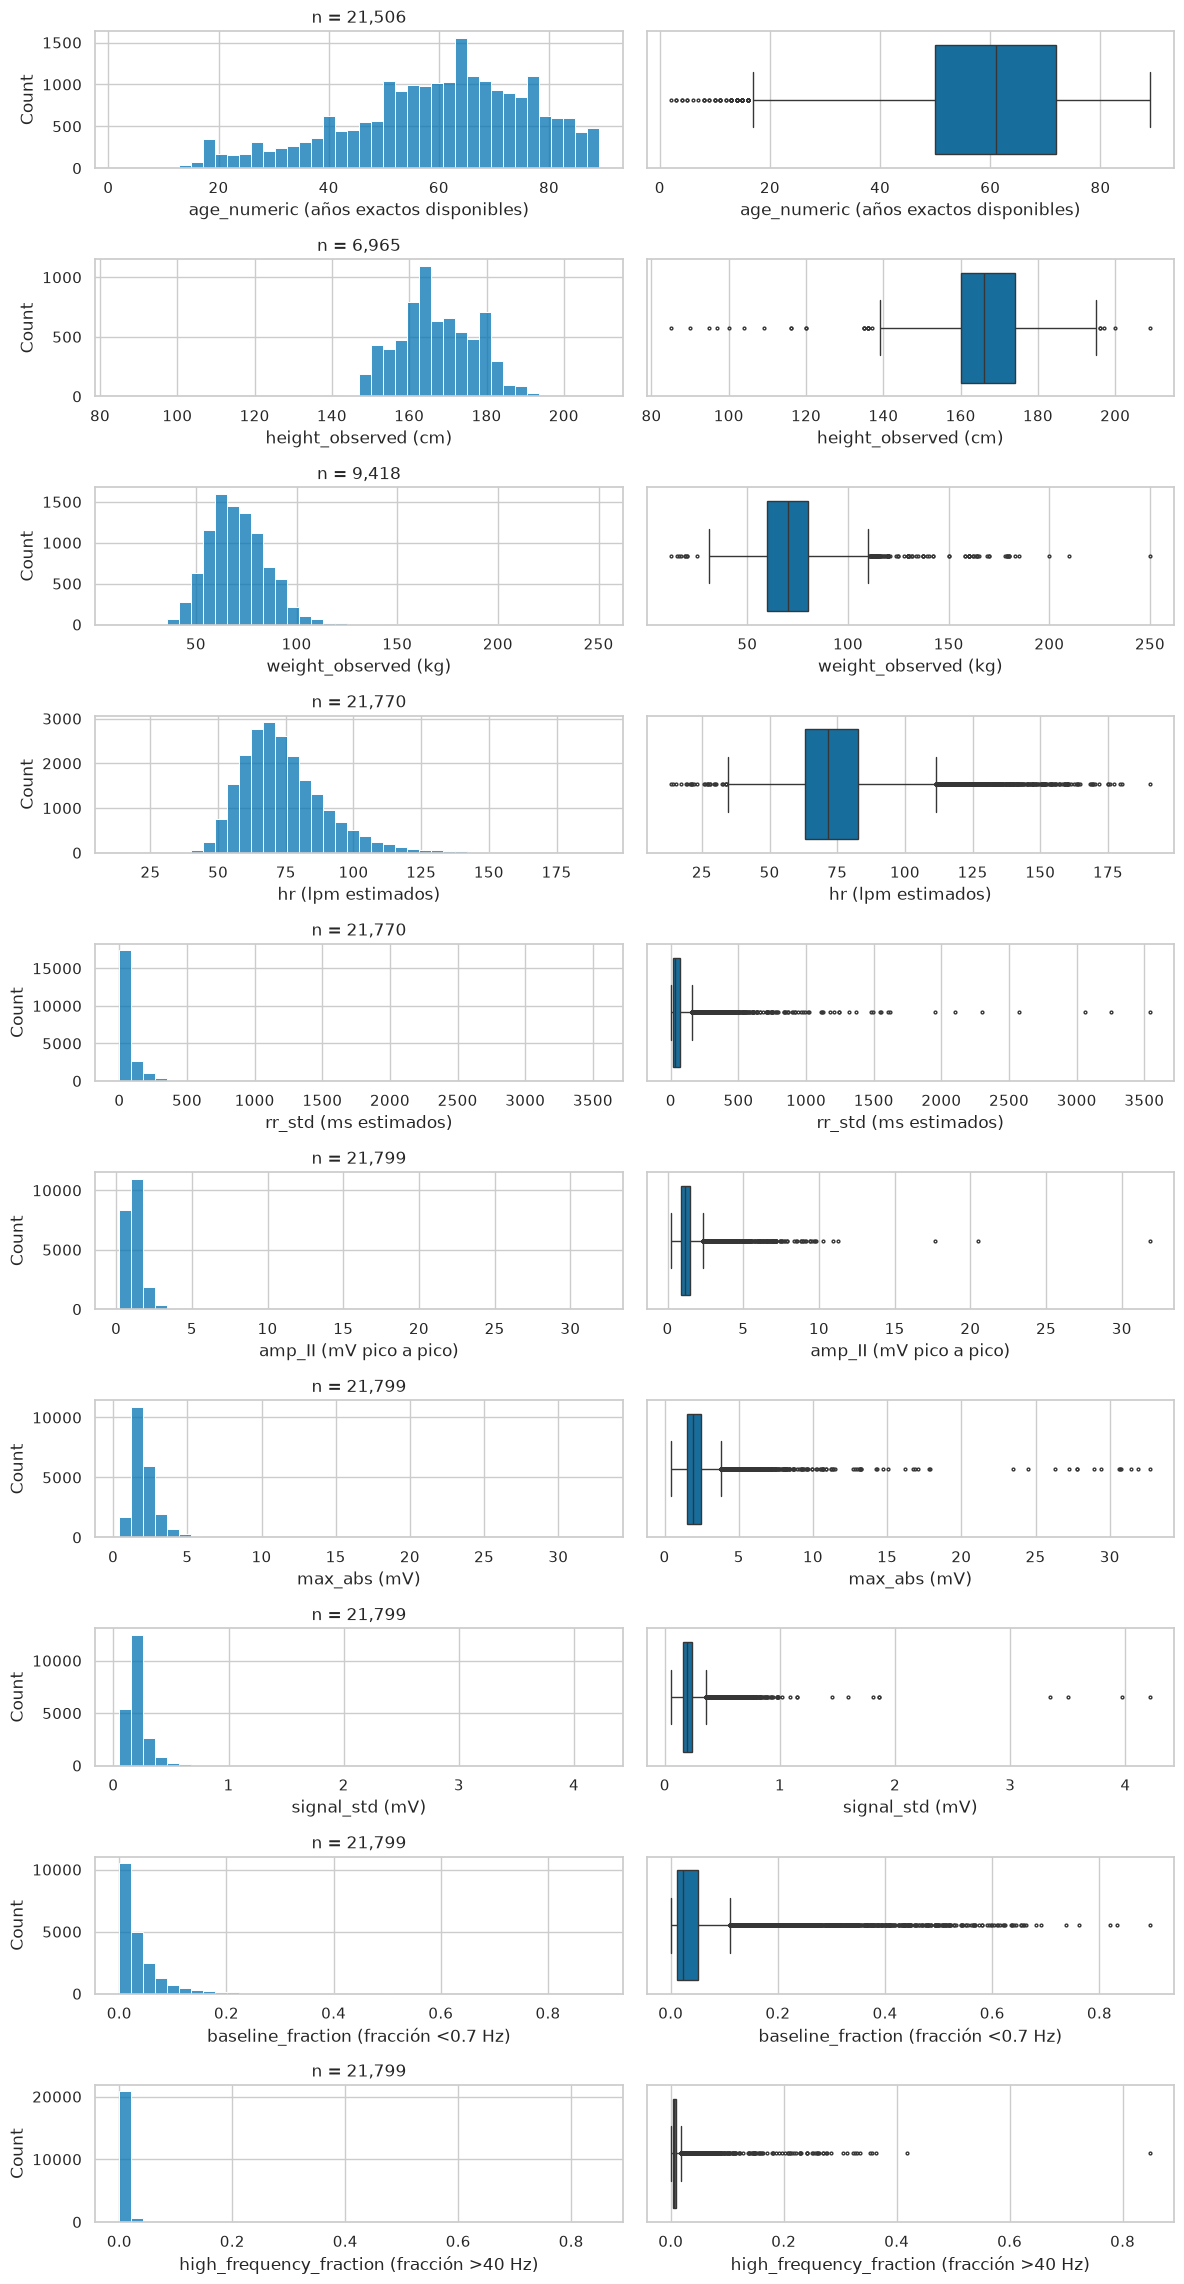

,count,unique,top,freq
sex,21799,2,0,11354
nurse,20326.0,12.0,0.0,8295.0
site,21782.0,51.0,0.0,8940.0
device,21799,11,CS100 3,6140
heart_axis,13331,8,MID,7687
infarction_stadium1,5612,6,unknown,3430
infarction_stadium2,103,3,Stadium III,65
validated_by,12421.0,12.0,0.0,6120.0
second_opinion,21799,2,False,21244
initial_autogenerated_report,21799,2,False,14986


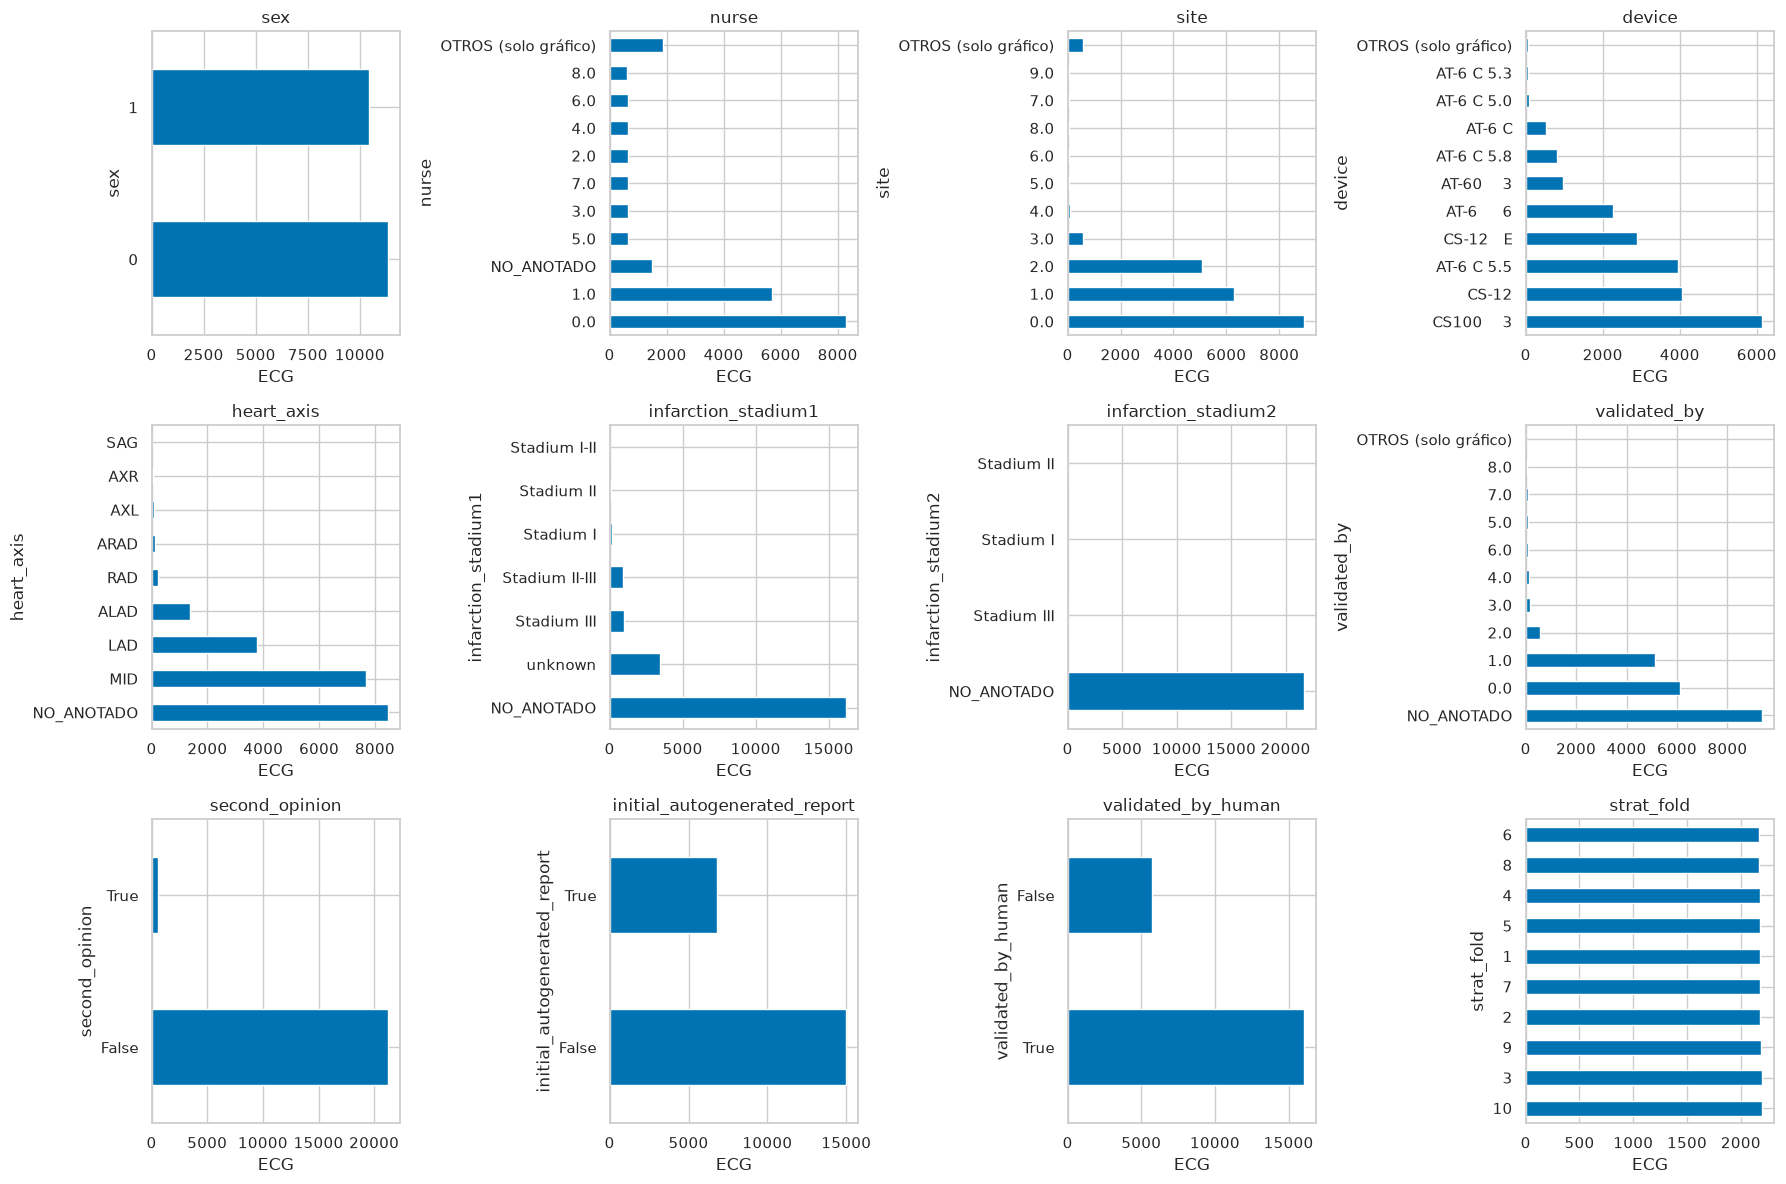

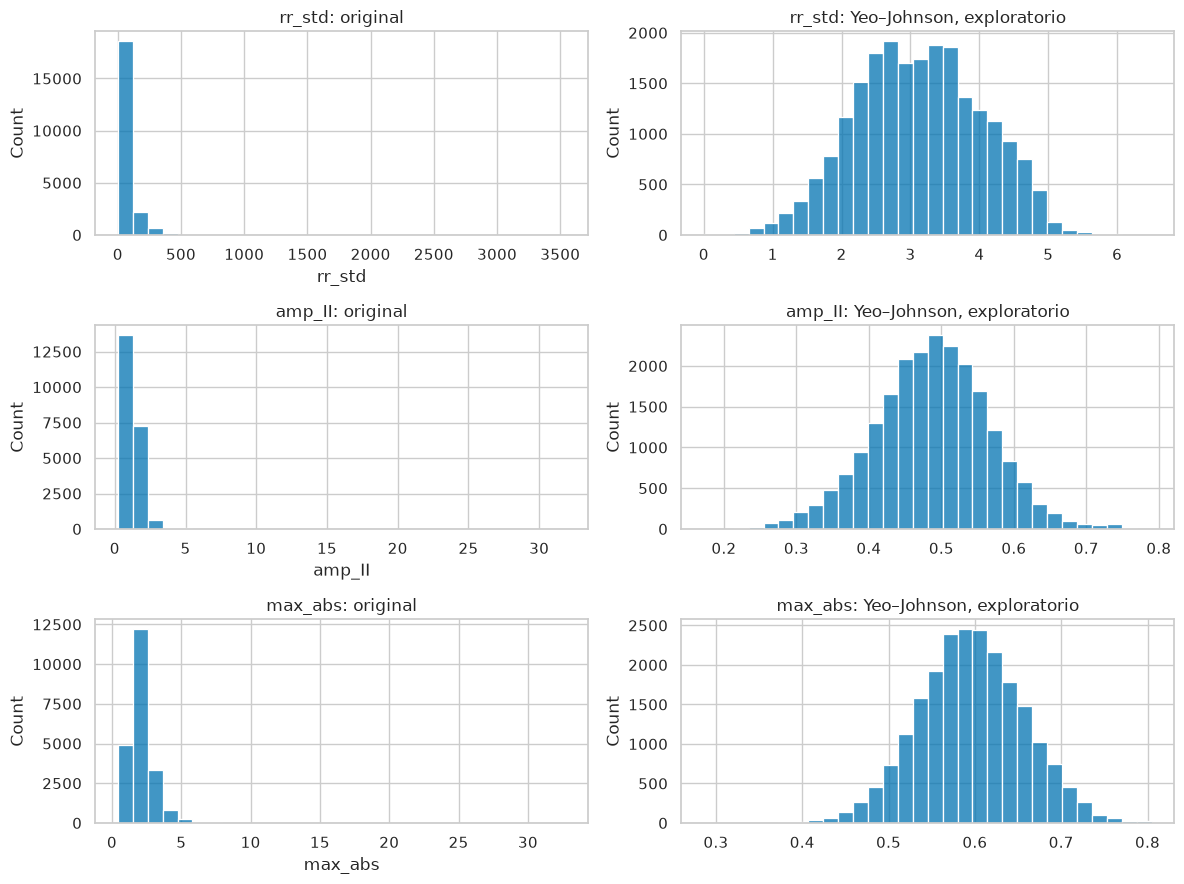

,variable,n,original,log1p,Yeo_Johnson,lambda_descriptivo
0,rr_std,21770,10.054539,0.163441,0.009703,-0.058338
1,amp_II,21799,8.660852,1.503733,-0.033550,-1.249773
2,max_abs,21799,9.289125,1.499540,-0.002049,-1.226092


In [7]:
SIGNAL_NUM = ["hr", "rr_std", "amp_II", "max_abs", "signal_std", "baseline_fraction", "high_frequency_fraction"]
eda = clean.join(signal_analysis[SIGNAL_NUM])
NUM = ["age_numeric", "height_observed", "weight_observed", *SIGNAL_NUM]
units_numeric = {"age_numeric":"años exactos disponibles", "height_observed":"cm", "weight_observed":"kg",
    "hr":"lpm estimados", "rr_std":"ms estimados", "amp_II":"mV pico a pico", "max_abs":"mV", "signal_std":"mV",
    "baseline_fraction":"fracción <0.7 Hz", "high_frequency_fraction":"fracción >40 Hz"}
num_summary = eda[NUM].describe().T
num_summary["asimetria"] = eda[NUM].skew()
outlier_rows=[]
for col in NUM:
    s=eda[col].dropna()
    q1,q3=s.quantile([.25,.75]); lo,hi=q1-1.5*(q3-q1),q3+1.5*(q3-q1)
    outlier_rows.append({"variable":col,"n_validos":len(s),"limite_inferior":lo,"limite_superior":hi,
                         "n_marcados":int((~s.between(lo,hi)).sum()),"pct_marcados":100*(~s.between(lo,hi)).mean()})
display(num_summary.round(3))
outlier_table = pd.DataFrame(outlier_rows).set_index("variable")
display(outlier_table.round(3))
fig, axes=plt.subplots(len(NUM),2,figsize=(12,2.3*len(NUM)))
for i,col in enumerate(NUM):
    s=eda[col].dropna()
    sns.histplot(x=s,bins=40,ax=axes[i,0])
    sns.boxplot(x=s,ax=axes[i,1],fliersize=2)
    for ax in axes[i]: ax.set_xlabel(f"{col} ({units_numeric[col]})")
    axes[i,0].set_title(f"n = {len(s):,}")
plt.tight_layout(); plt.show()
display(raw[cat_cols].astype("object").describe().T)
fig,axes=plt.subplots(3,4,figsize=(18,12))
for ax,col in zip(axes.flat,cat_cols):
    vc=raw[col].astype("string").fillna("NO_ANOTADO").value_counts()
    shown=vc.head(10).copy()
    if len(vc)>10: shown.loc["OTROS (solo gráfico)"]=vc.iloc[10:].sum()
    shown.plot.barh(ax=ax,title=col,xlabel="ECG")
for ax in list(axes.flat)[len(cat_cols):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

skew_rows=[]
fig,axes=plt.subplots(3,2,figsize=(12,9))
for i,col in enumerate(["rr_std","amp_II","max_abs"]):
    s=signal_analysis[col].dropna()
    if len(s)>3 and s.nunique()>1:
        yj,lam=stats.yeojohnson(s)
        skew_rows.append({"variable":col,"n":len(s),"original":s.skew(),"log1p":np.log1p(s).skew(),
                          "Yeo_Johnson":pd.Series(yj).skew(),"lambda_descriptivo":lam})
        sns.histplot(s,bins=30,ax=axes[i,0]); sns.histplot(yj,bins=30,ax=axes[i,1])
        axes[i,0].set_title(f"{col}: original"); axes[i,1].set_title(f"{col}: Yeo–Johnson, exploratorio")
plt.tight_layout(); plt.show()
skew_comparison=pd.DataFrame(skew_rows)
display(skew_comparison)
num_summary.to_csv(OUT / "estadisticas_numericas.csv")
outlier_table.to_csv(OUT / "atipicos_iqr.csv")
skew_comparison.to_csv(OUT / "asimetria.csv", index=False)


## 7. Relaciones bi/multivariantes y dimensión temporal

Se muestran matrices numéricas y gráficas; no se confunde correlación baja con ausencia de información
predictiva no lineal. Los grupos multietiqueta se solapan. Cada tabla informa cuántos pares fueron observados.
La matriz principal es descriptiva por ECG; una sensibilidad usa un ECG por paciente para reducir
la sobrerrepresentación de quienes tienen varios registros. No se reportan p-valores suponiendo
independencia entre ECG de una misma persona.

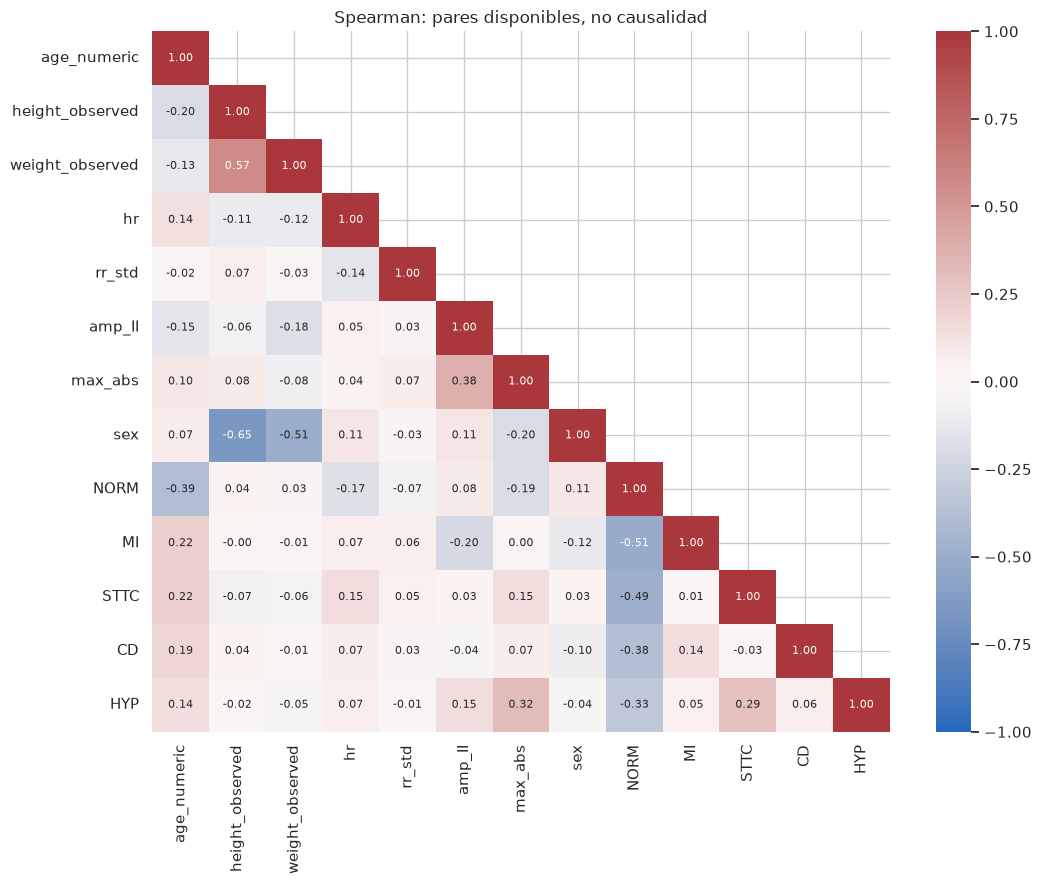

,NORM,MI,STTC,CD,HYP
age_numeric,-0.389,0.222,0.224,0.191,0.143
height_observed,0.035,-0.004,-0.072,0.037,-0.025
weight_observed,0.025,-0.006,-0.062,-0.012,-0.053
hr,-0.173,0.069,0.151,0.070,0.068
rr_std,-0.070,0.058,0.048,0.026,-0.010
amp_II,0.082,-0.205,0.032,-0.044,0.149
max_abs,-0.193,0.002,0.152,0.072,0.319


,NORM,MI,STTC,CD,HYP
age_numeric,21506,21506,21506,21506,21506
height_observed,6965,6965,6965,6965,6965
weight_observed,9418,9418,9418,9418,9418
hr,21770,21770,21770,21770,21770
rr_std,21770,21770,21770,21770,21770
amp_II,21799,21799,21799,21799,21799
max_abs,21799,21799,21799,21799,21799


,NORM,MI,STTC,CD,HYP
age_numeric,-0.395,0.232,0.227,0.197,0.148
height_observed,0.033,-0.004,-0.073,0.041,-0.020
weight_observed,0.019,-0.006,-0.055,-0.011,-0.046
hr,-0.164,0.071,0.143,0.063,0.066
rr_std,-0.065,0.061,0.047,0.025,-0.010
amp_II,0.076,-0.194,0.034,-0.038,0.151
max_abs,-0.191,0.013,0.151,0.065,0.319


,NORM,MI,STTC,CD,HYP
age_numeric,18612,18612,18612,18612,18612
height_observed,6619,6619,6619,6619,6619
weight_observed,8827,8827,8827,8827,8827
hr,18850,18850,18850,18850,18850
rr_std,18850,18850,18850,18850,18850
amp_II,18869,18869,18869,18869,18869
max_abs,18869,18869,18869,18869,18869


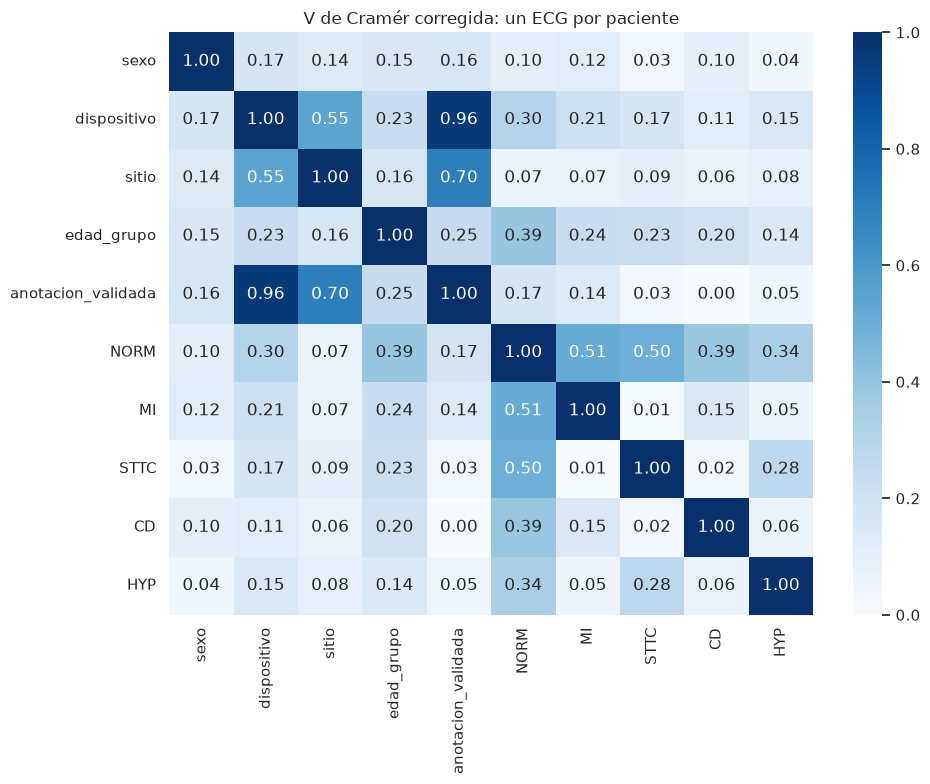

,NORM,MI,STTC,CD,HYP
sexo,0.103168,0.115740,0.031868,0.097093,0.041950
dispositivo,0.302459,0.214268,0.171718,0.109799,0.145068
sitio,0.065583,0.067677,0.090413,0.064834,0.083942
edad_grupo,0.394421,0.235330,0.227527,0.199626,0.141465


ECG/pacientes en la matriz categórica: 18869


In [8]:
relation_cols = ["age_numeric", "height_observed", "weight_observed", "hr", "rr_std", "amp_II", "max_abs"]
corr_frame=pd.concat([eda[relation_cols],raw.sex,Y],axis=1)
spearman=corr_frame.corr(method="spearman")
pair_counts=corr_frame.notna().astype("int64").T @ corr_frame.notna().astype("int64")
fig,ax=plt.subplots(figsize=(11,9))
sns.heatmap(spearman,mask=np.triu(np.ones_like(spearman,dtype=bool),k=1),annot=True,fmt=".2f",
            cmap="vlag",vmin=-1,vmax=1,center=0,annot_kws={"size":8},ax=ax)
ax.set_title("Spearman: pares disponibles, no causalidad")
plt.tight_layout(); plt.show()
display(spearman.loc[relation_cols,SUPERCLASSES].round(3))
display(pair_counts.loc[relation_cols,SUPERCLASSES])
one_per_patient=clean.sort_index().drop_duplicates("patient_id").index
sensitivity_corr = corr_frame.loc[one_per_patient].corr(method="spearman")
sensitivity_n = corr_frame.loc[one_per_patient].notna().astype("int64")
sensitivity_n = sensitivity_n.T @ sensitivity_n
display(sensitivity_corr.loc[relation_cols,SUPERCLASSES].round(3))
display(sensitivity_n.loc[relation_cols,SUPERCLASSES])

nominal=pd.DataFrame({"sexo":raw.sex.astype(str),"dispositivo":clean.device_normalized,
    "sitio":clean.site_grouped,"edad_grupo":clean.age_band,
    "anotacion_validada":raw.validated_by_human.astype(str)})
for sc in SUPERCLASSES: nominal[sc]=Y[sc].astype(str)
v=pd.DataFrame({b:{a:cramers_v(nominal.loc[one_per_patient,a],nominal.loc[one_per_patient,b])
                     for a in nominal} for b in nominal})
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(v,annot=True,fmt=".2f",vmin=0,vmax=1,cmap="Blues",ax=ax)
ax.set_title("V de Cramér corregida: un ECG por paciente")
plt.tight_layout(); plt.show()
display(v.loc[["sexo","dispositivo","sitio","edad_grupo"],SUPERCLASSES])
print("ECG/pacientes en la matriz categórica:", len(one_per_patient))
spearman.to_csv(OUT / "spearman.csv")
pair_counts.to_csv(OUT / "pares_spearman.csv")
sensitivity_corr.to_csv(OUT / "spearman_un_ecg_por_paciente.csv")
v.to_csv(OUT / "cramer_v.csv")


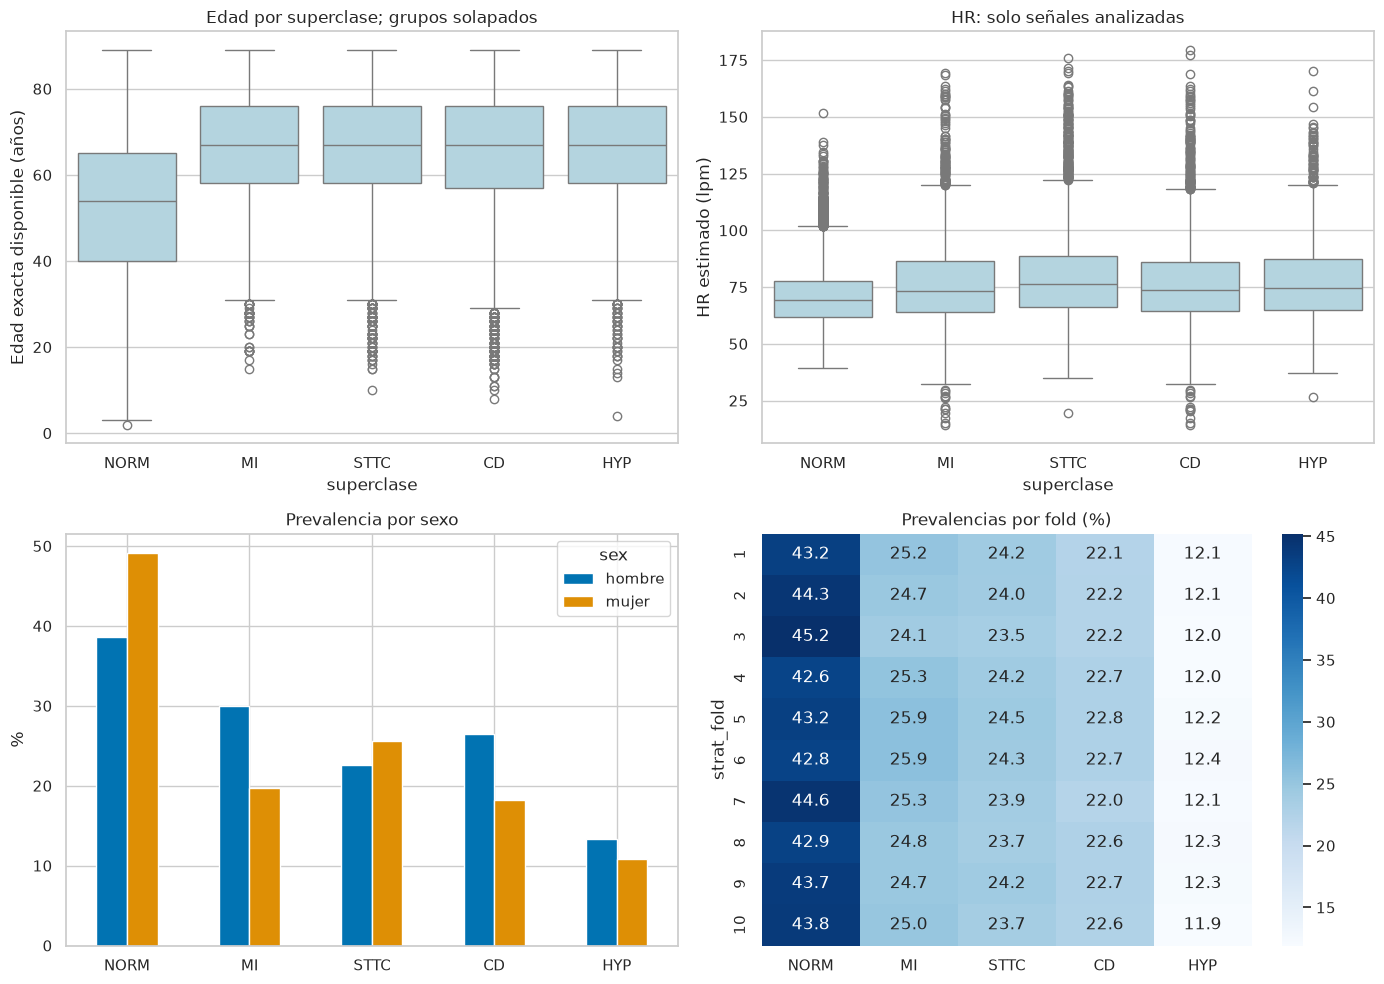

,NORM,MI,STTC,CD,HYP
age_band,,,,,
0–17,81.203008,1.503759,5.263158,18.045113,3.759398
18–29,85.714286,2.487961,5.858748,10.112360,3.130016
30–44,73.219151,9.147528,9.770339,11.405216,6.656286
45–59,51.947604,21.957946,19.251982,16.821786,8.927956
60–74,33.373559,30.933226,28.197908,25.422365,14.843121
75–89,21.475105,34.876687,36.016752,33.527222,17.519777
90+ (censurada),10.580205,41.296928,46.416382,48.464164,19.112628


age_numeric           hr           
                 count median count     median
superclase                                    
CD                4756   67.0  4884  73.833763
HYP               2593   67.0  2646  74.643746
MI                5348   67.0  5460  73.219436
NORM              9483   54.0  9514  69.092584
STTC              5099   67.0  5235  76.265311

,min_pct,max_pct,rango_puntos_pct
NORM,42.640294,45.209854,2.569560
MI,24.087591,25.896964,1.809373
STTC,23.494526,24.471021,0.976496
CD,21.966912,22.815087,0.848176
HYP,11.919927,12.425219,0.505291


,size,mean
strat_fold,,
1,2175,0.672644
2,2181,0.662999
3,2192,0.669708
4,2174,0.681233
5,2174,0.677093
6,2173,0.641509
7,2176,0.679228
8,2173,0.677865
9,2183,1.000000


,n_ECG,n_senales,n_HR_estimado,baseline_mediana,prev_NORM,prev_MI,prev_STTC,prev_CD,prev_HYP
device_normalized,,,,,,,,,
AT-6 6,2273,2273,2272,0.043506,0.439067,0.221733,0.286846,0.226133,0.136384
AT-6 C,514,514,514,0.029536,0.233463,0.356031,0.354086,0.289883,0.169261
AT-6 C 5.0,80,80,80,0.033149,0.262500,0.312500,0.400000,0.225000,0.175000
AT-6 C 5.3,67,67,67,0.050030,0.567164,0.179104,0.179104,0.208955,0.179104
AT-6 C 5.5,3950,3950,3948,0.038074,0.476456,0.198734,0.266835,0.225823,0.157215
AT-6 C 5.6,59,59,59,0.040021,0.559322,0.169492,0.237288,0.186441,0.186441
AT-6 C 5.8,824,824,822,0.044935,0.408981,0.212379,0.308252,0.245146,0.155340
AT-60 3,966,966,962,0.009785,0.418219,0.311594,0.229814,0.218427,0.073499
CS-12,4048,4048,4042,0.025738,0.408844,0.262352,0.235425,0.276186,0.092638


In [9]:
by_sex=Y.groupby(raw.sex.map({0:"hombre",1:"mujer"})).mean()*100
by_age=Y.groupby(clean.age_band,observed=True).mean()*100
by_fold=Y.groupby(raw.strat_fold).mean()*100
long=pd.concat([eda[["age_numeric","hr"]].loc[Y[sc].eq(1)].assign(superclase=sc) for sc in SUPERCLASSES], ignore_index=True)
fig,axes=plt.subplots(2,2,figsize=(14,10))
sns.boxplot(data=long,x="superclase",y="age_numeric",ax=axes[0,0],color="lightblue")
axes[0,0].set(ylabel="Edad exacta disponible (años)",title="Edad por superclase; grupos solapados")
sns.boxplot(data=long,x="superclase",y="hr",ax=axes[0,1],color="lightblue")
axes[0,1].set(ylabel="HR estimado (lpm)",title="HR: solo señales analizadas")
by_sex.T.plot.bar(ax=axes[1,0],rot=0,ylabel="%",title="Prevalencia por sexo")
sns.heatmap(by_fold,annot=True,fmt=".1f",cmap="Blues",ax=axes[1,1])
axes[1,1].set_title("Prevalencias por fold (%)")
plt.tight_layout(); plt.show()
display(by_age)
display(long.groupby("superclase")[["age_numeric","hr"]].agg(["count","median"]))
display(pd.DataFrame({"min_pct":by_fold.min(),"max_pct":by_fold.max(),"rango_puntos_pct":by_fold.max()-by_fold.min()}))
display(raw.groupby("strat_fold").validated_by_human.agg(["size","mean"]))
# Dispositivo: asociación descriptiva, no prueba del filtro interno utilizado.
device_table=eda.groupby("device_normalized").agg(n_ECG=("patient_id","size"),
    n_senales=("signal_std","count"), n_HR_estimado=("hr","count"),baseline_mediana=("baseline_fraction","median"))
display(device_table.join(Y.groupby(clean.device_normalized).mean().add_prefix("prev_")))
by_sex.to_csv(OUT / "prevalencia_sexo.csv")
by_age.to_csv(OUT / "prevalencia_edad.csv")
by_fold.to_csv(OUT / "prevalencia_fold.csv")
category_summary = long.groupby("superclase")[["age_numeric", "hr"]].agg(["count", "median"])
category_summary.to_csv(OUT / "resumen_por_superclase.csv")


### Tiempo: lo que sí y lo que no puede inferirse

Se pueden resumir las **fechas publicadas desplazadas** y los intervalos intrapaciente.
No se interpretan como años reales de cambio de protocolos, equipos o salud poblacional.
Los gráficos siguientes auditan la variable publicada, no reconstruyen el calendario original.

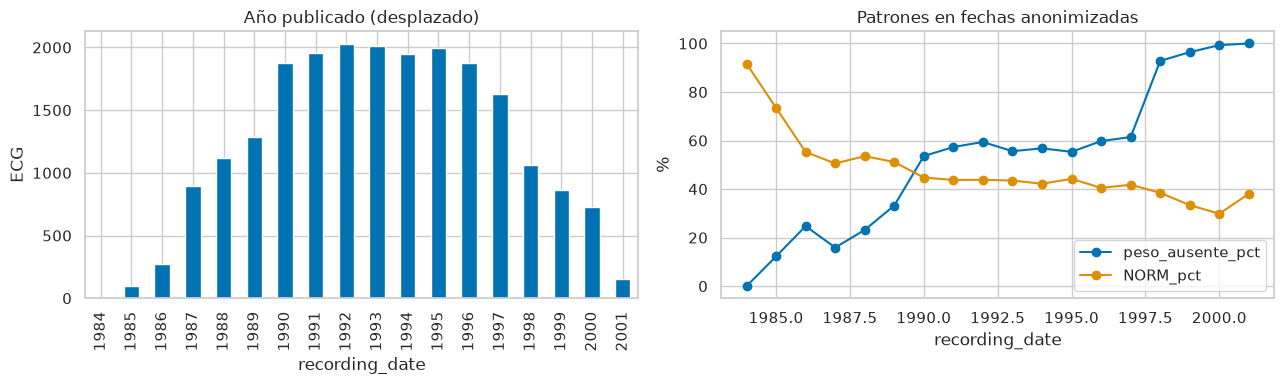

,intervalo_intrapaciente_dias
count,2930.000000
mean,106.864018
std,227.810520
min,0.000000
25%,3.036782
50%,10.931887
75%,85.711823
max,1707.121053


,ECG,peso_ausente_pct,NORM_pct
recording_date,,,
1984,12,0.000000,91.666667
1985,98,12.244898,73.469388
1986,275,24.727273,55.272727
1987,894,15.883669,50.559284
1988,1122,23.172906,53.565062
1989,1283,33.203429,51.130164
1990,1875,53.600000,44.746667
1991,1952,57.325820,43.750000
1992,2027,59.398125,43.808584


In [10]:
year=meta.recording_date.dt.year
by_year=pd.DataFrame({"ECG":year.value_counts().sort_index(),
    "peso_ausente_pct":raw.weight.isna().groupby(year).mean()*100,
    "NORM_pct":Y.NORM.groupby(year).mean()*100})
fig,axes=plt.subplots(1,2,figsize=(13,4))
by_year.ECG.plot.bar(ax=axes[0],title="Año publicado (desplazado)",ylabel="ECG")
by_year[["peso_ausente_pct","NORM_pct"]].plot(ax=axes[1],marker="o",ylabel="%",title="Patrones en fechas anonimizadas")
plt.tight_layout(); plt.show()
sorted_dates=meta.sort_values(["patient_id","recording_date"])
gaps_days=sorted_dates.groupby("patient_id").recording_date.diff().dt.total_seconds()/86400
display(gaps_days.dropna().describe().to_frame("intervalo_intrapaciente_dias"))
by_year.to_csv(OUT / "patrones_fecha_publicada.csv")
display(by_year)

## 8. Visualización de ECG y comparación 500/100 Hz

El dataset contiene señales, no imágenes. Los trazados se muestran en mV y segundos, con las mismas
escalas entre derivaciones. Los ejemplos por superclase ilustran registros concretos. Se compara la
señal original con un z-score por registro y derivación, que elimina la escala absoluta de amplitud.
La visualización principal conserva los mV. No se aplica filtrado a los trazados originales.


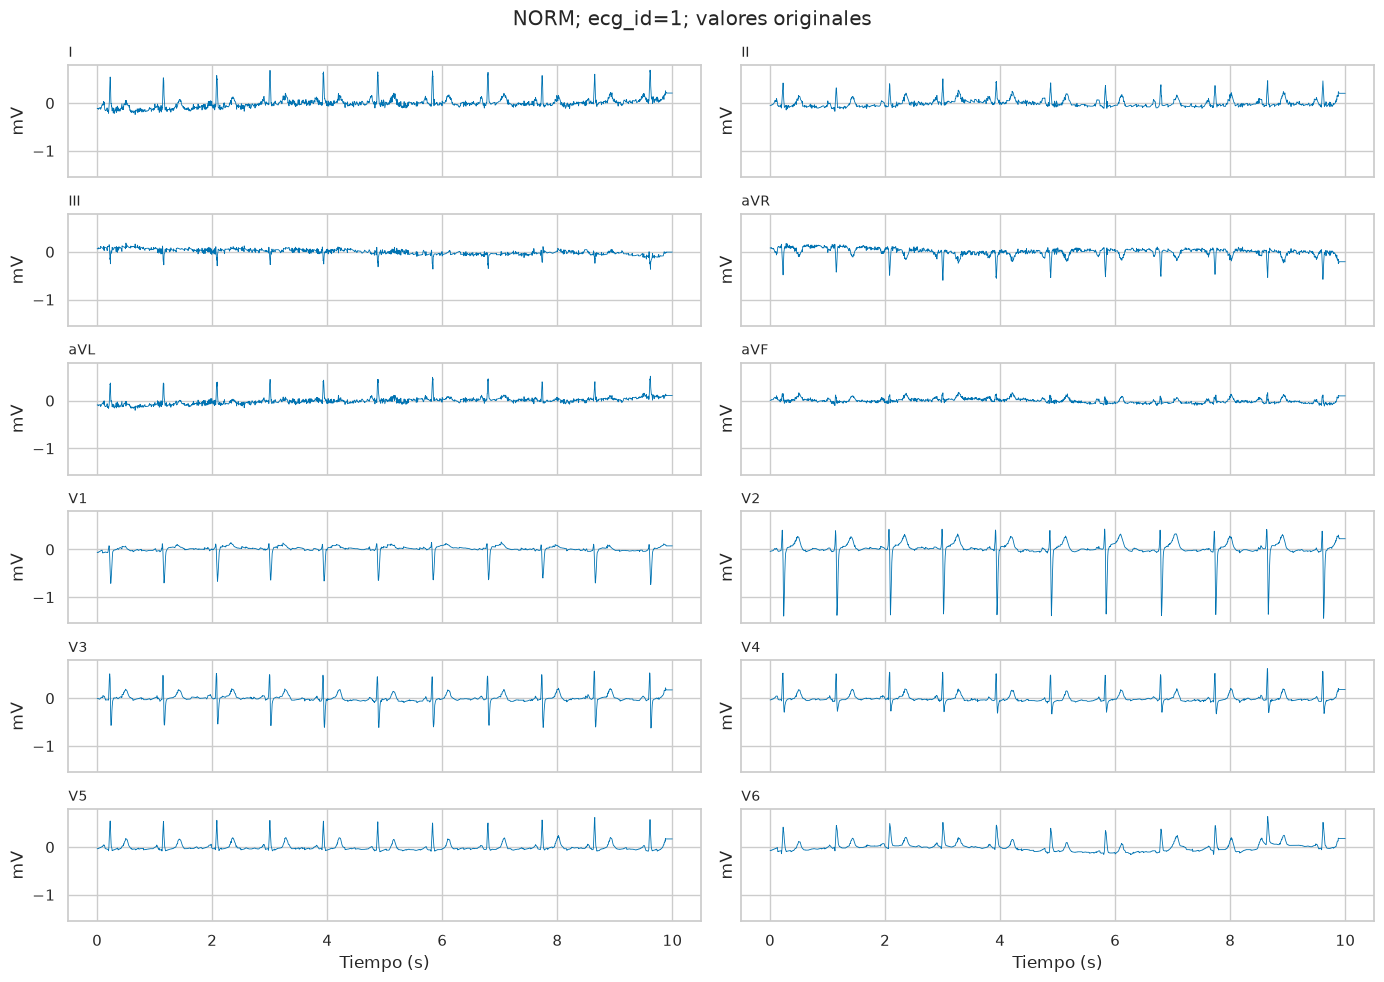

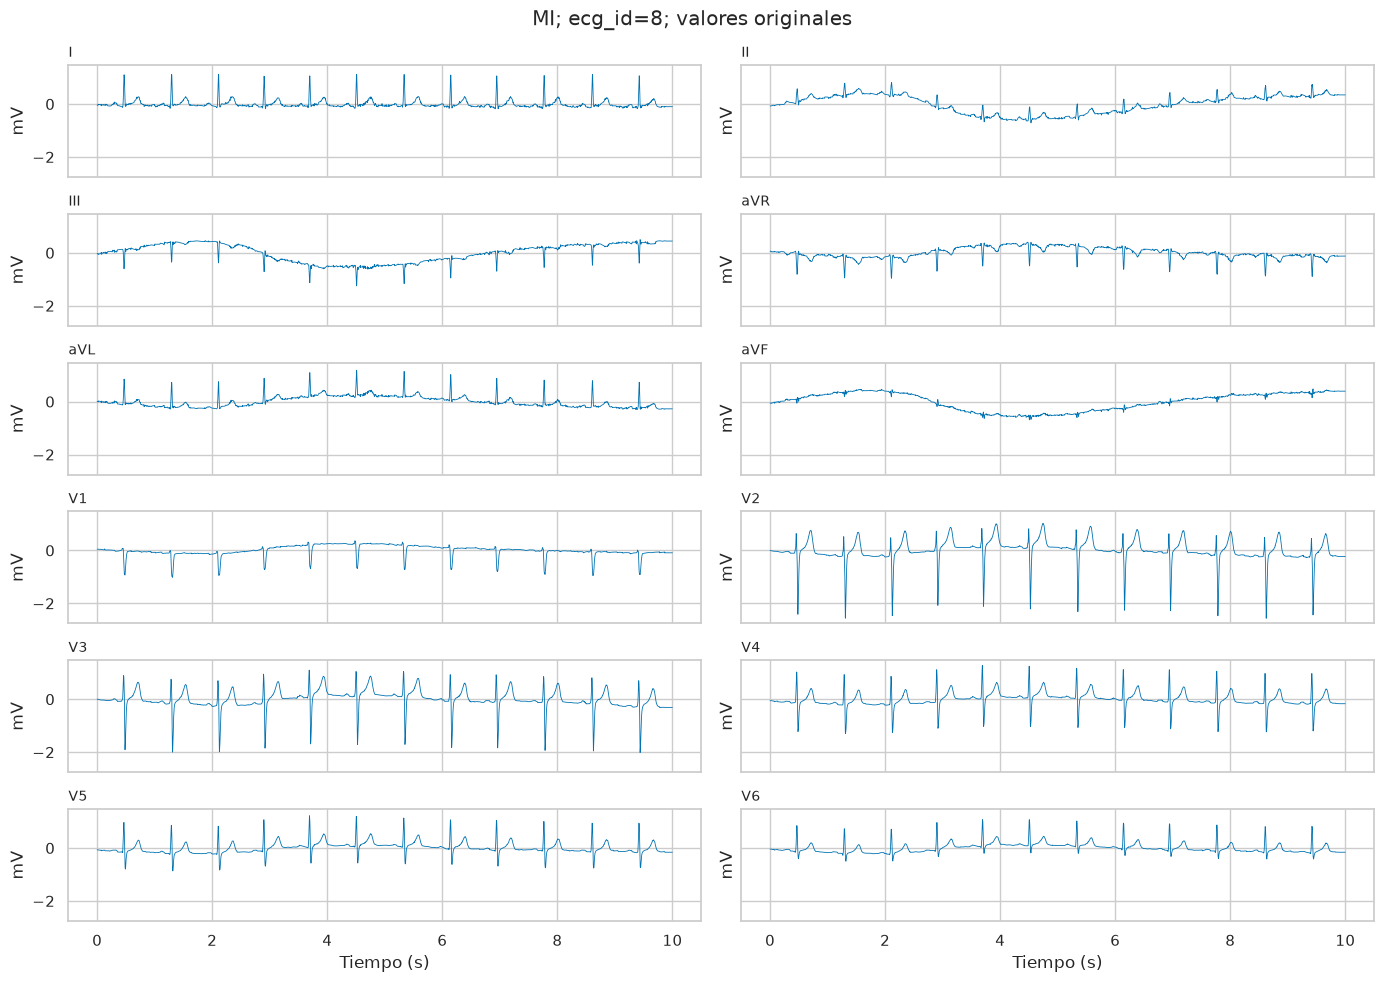

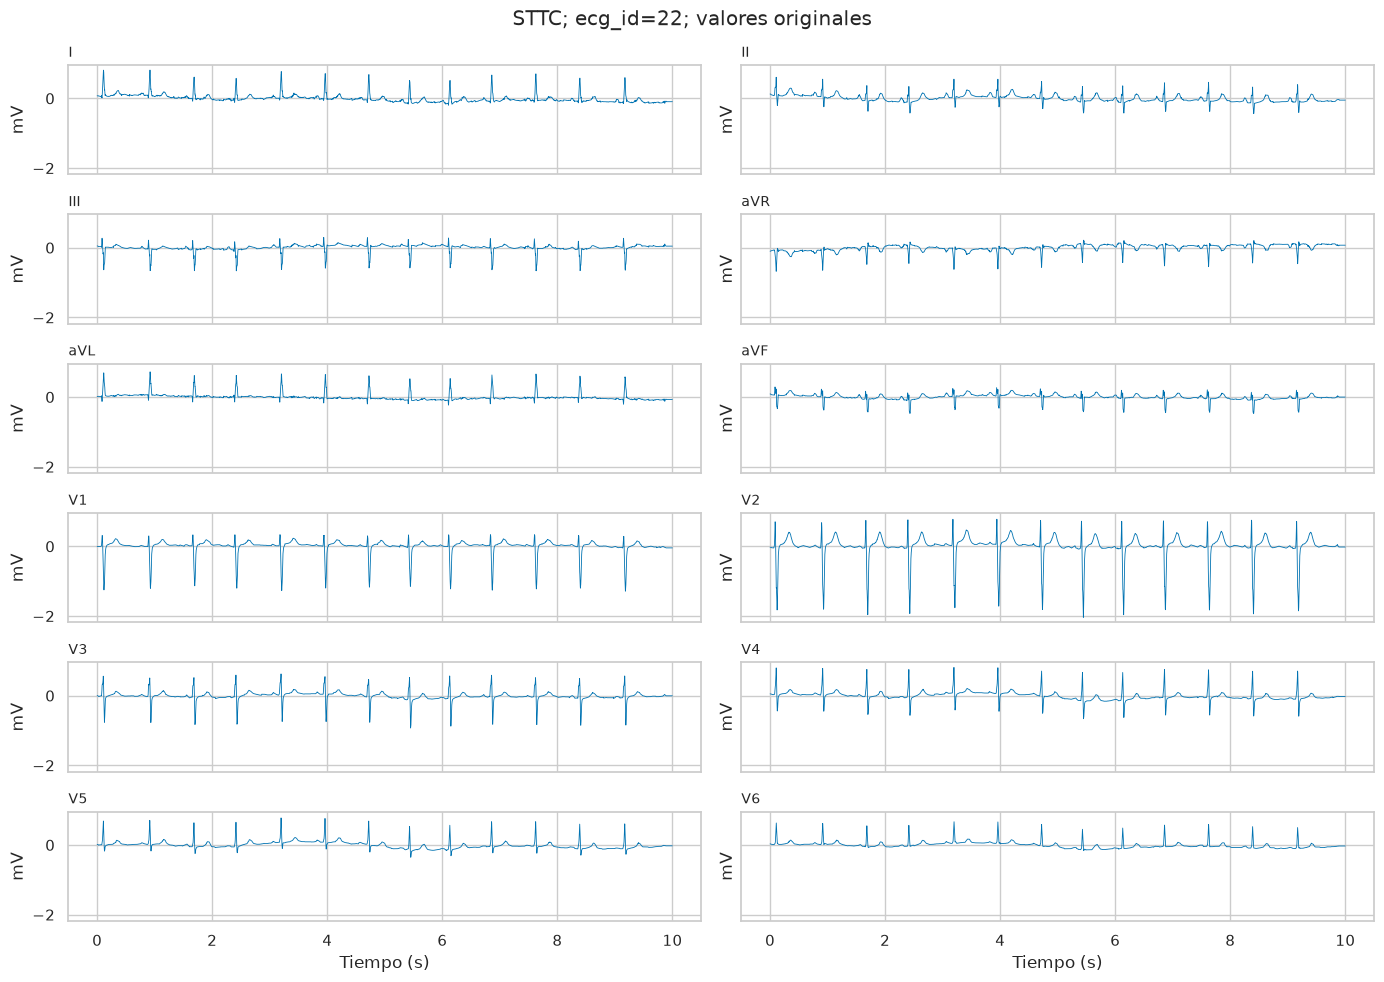

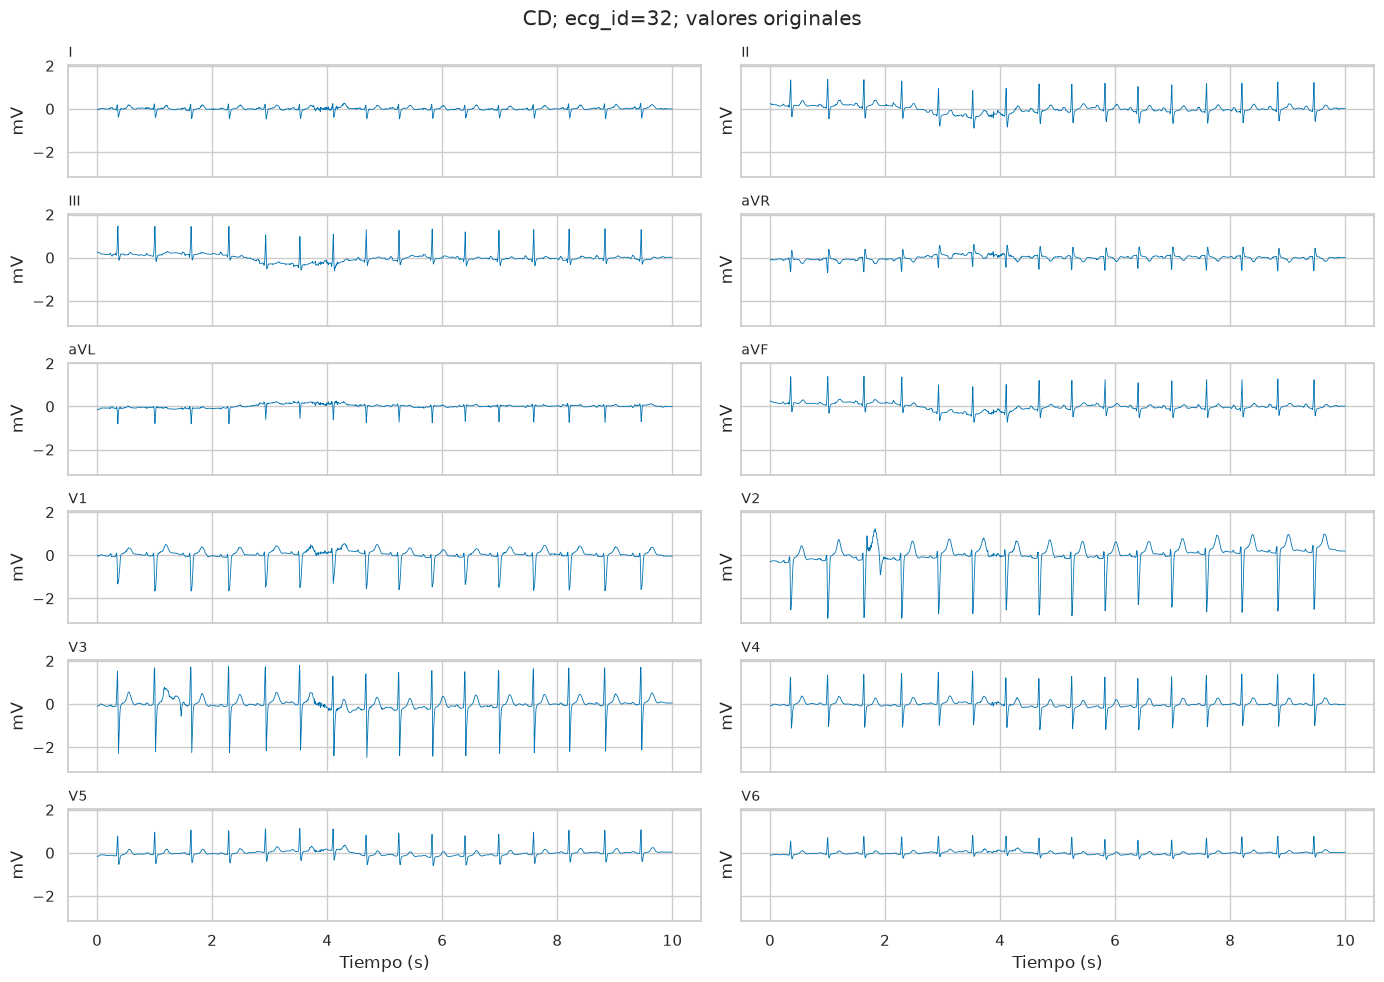

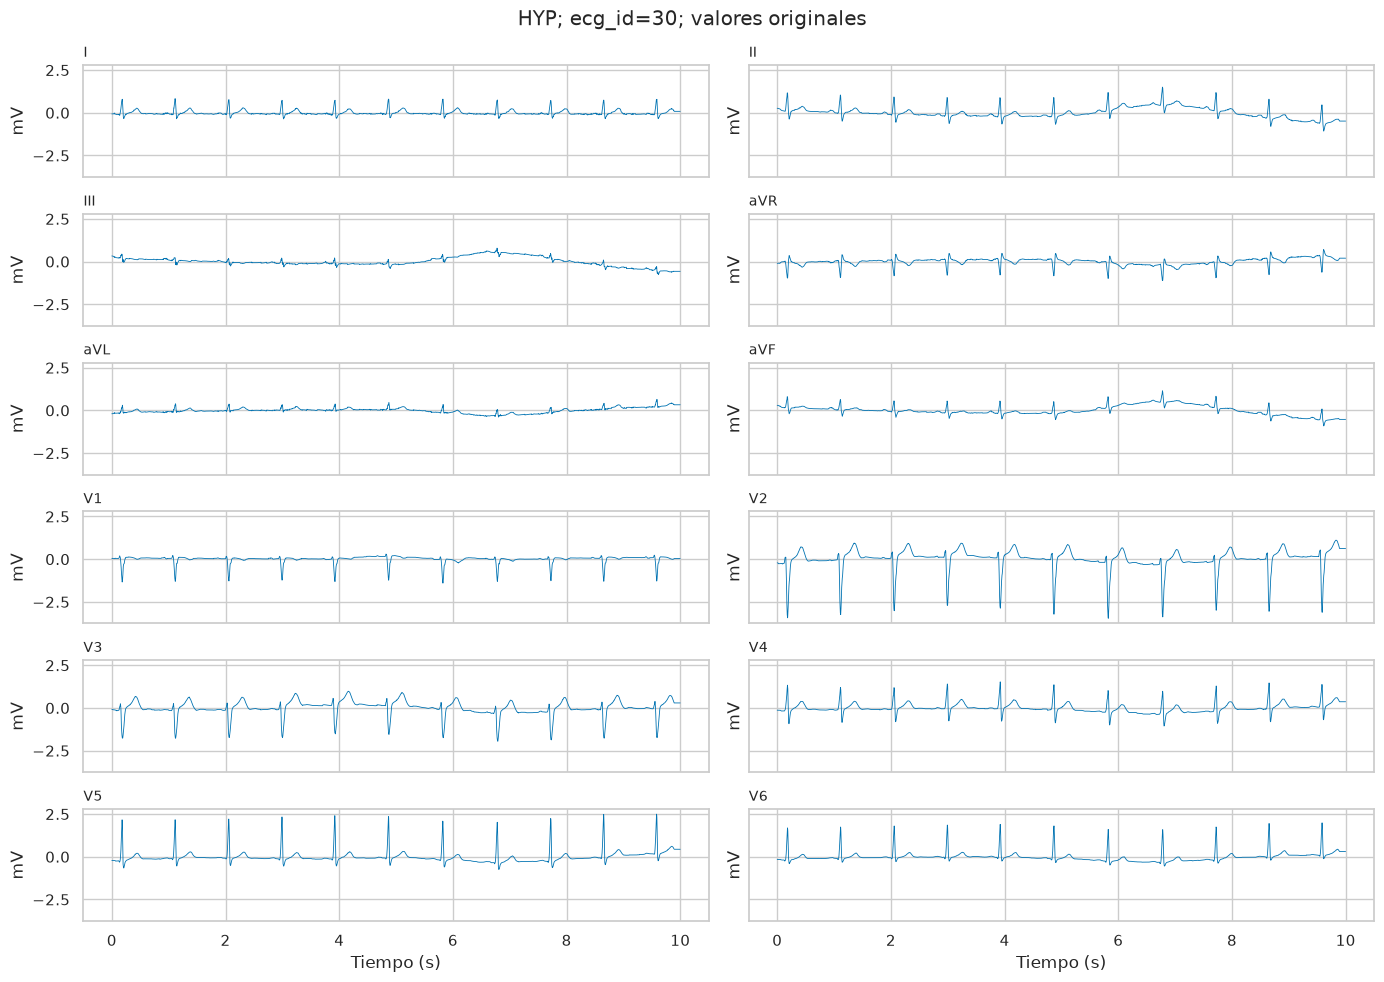

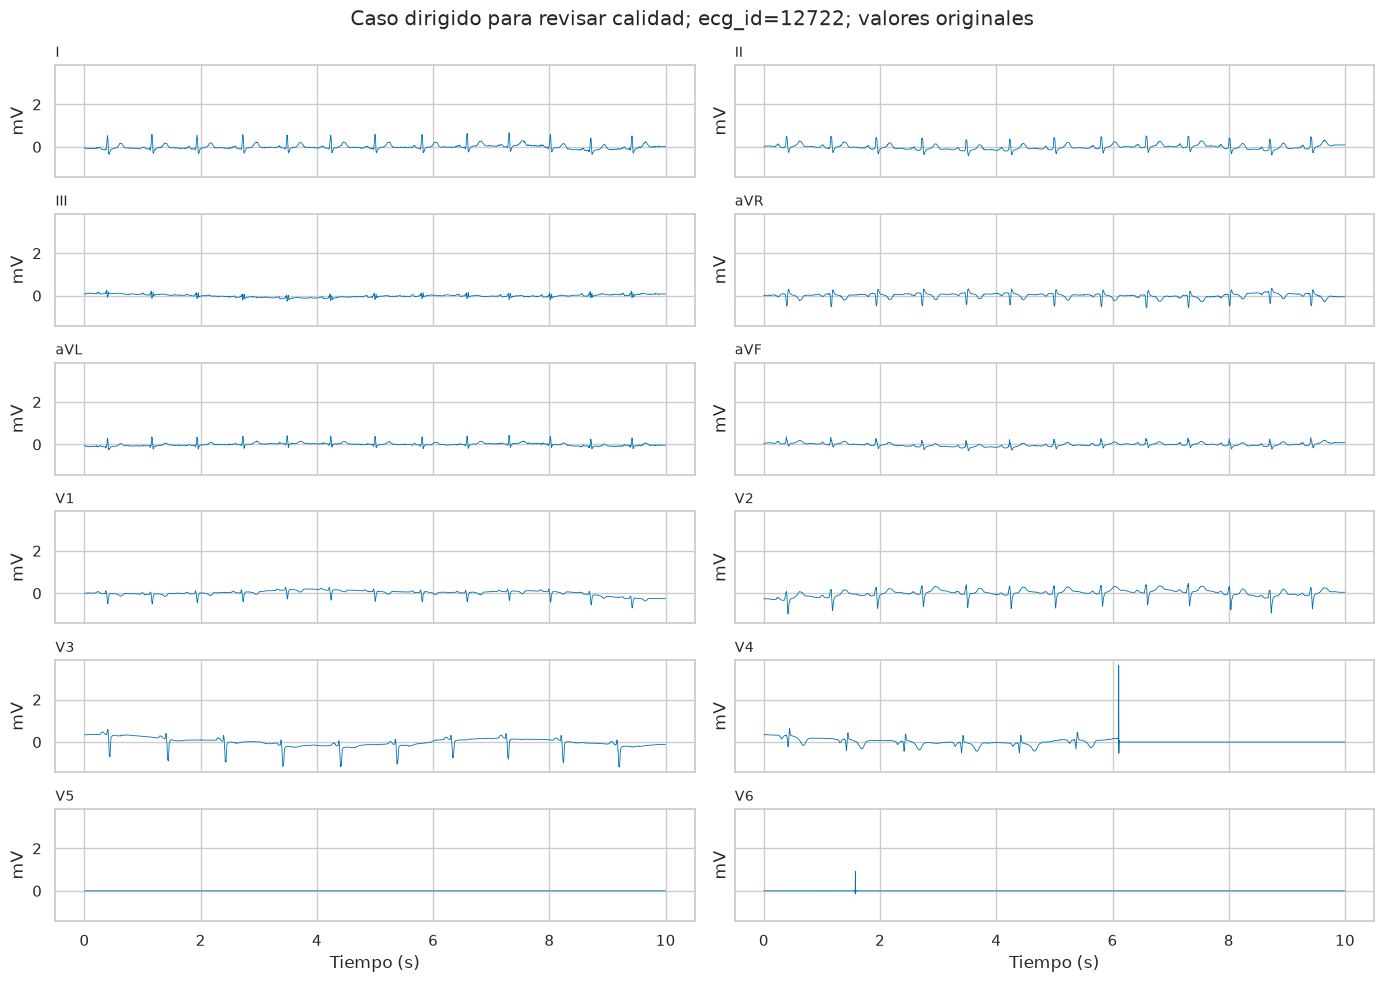

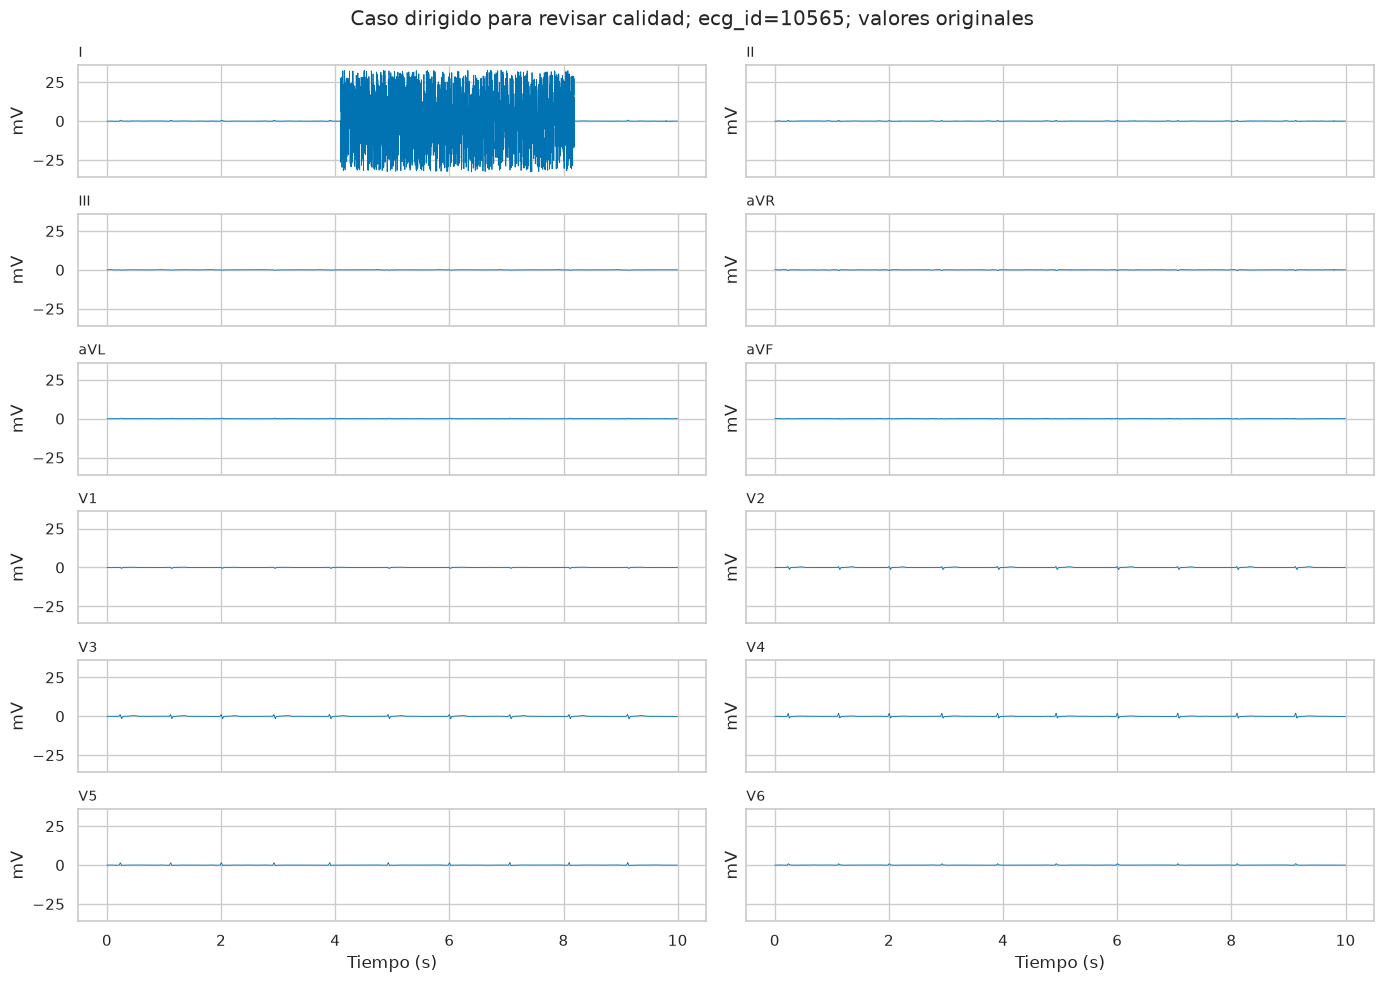

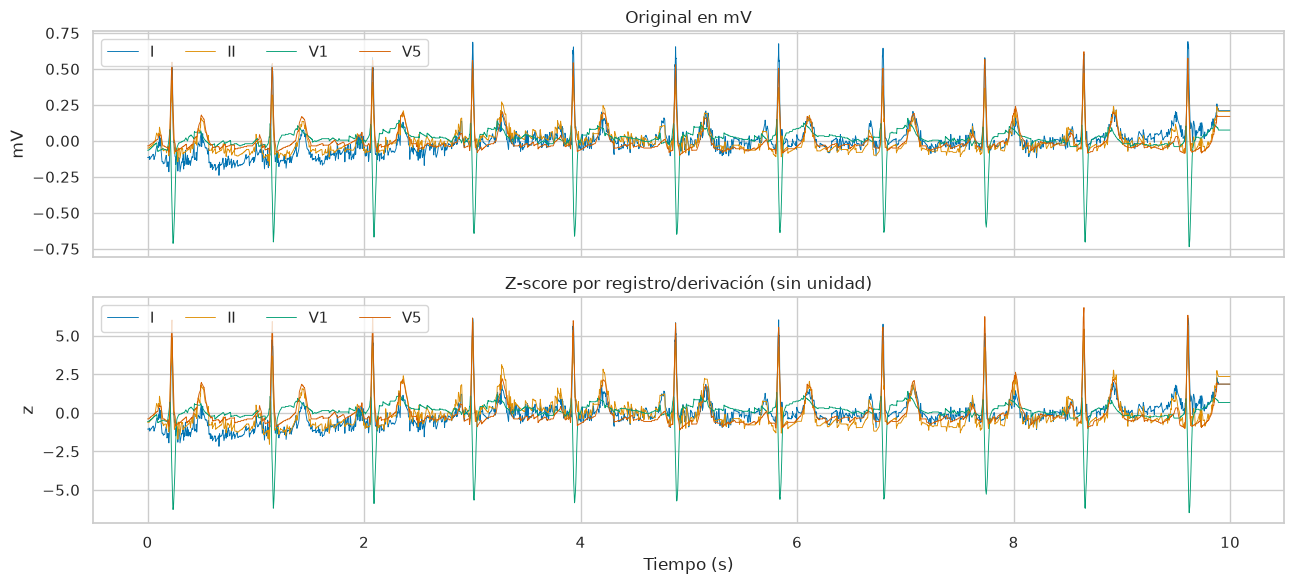

,correlacion,mediana_error_absoluto_mV,max_error_absoluto_mV
count,16.000000,16.000000,16.000000
mean,0.987987,0.001751,0.726329
std,0.020330,0.000822,0.821384
min,0.914888,0.000784,0.180503
25%,0.991370,0.001198,0.249881
50%,0.994120,0.001458,0.374852
75%,0.995936,0.002018,0.762943
max,0.997490,0.003614,3.322326


Comparación pareada: 16 ECG; omitidos por no disponer de records100: 0
Diferencias entre versiones/filtros no identifican por sí solas la causa ni el efecto diagnóstico.


,ECG,std_mediana_mV,minimo_mV,maximo_mV
lead,,,,
I,21799,0.130375,-32.692,32.716
II,21799,0.133677,-14.265,30.643
III,21799,0.109240,-27.253,30.655
aVR,21799,0.122383,-30.650,15.400
aVL,21799,0.099326,-30.692,27.174
aVF,21799,0.102638,-13.705,15.313
V1,21799,0.158421,-17.819,10.581
V2,21799,0.248962,-31.453,15.373
V3,21799,0.247093,-23.152,30.669


In [11]:
def plot_ecg(ecg_id,title):
    sig,fs=read_ecg(ecg_id)
    t=np.arange(len(sig))/fs
    fig,axes=plt.subplots(6,2,figsize=(14,10),sharex=True,sharey=True)
    for j,ax in enumerate(axes.flat):
        ax.plot(t,sig[:,j],lw=.6); ax.set_title(LEADS[j],loc="left",fontsize=10)
        ax.set_ylabel("mV")
    for ax in axes[-1]: ax.set_xlabel("Tiempo (s)")
    fig.suptitle(f"{title}; ecg_id={ecg_id}; valores originales")
    plt.tight_layout(); plt.show()
for sc in SUPERCLASSES:
    ids=[i for i in sorted(set(case_ids)) if meta.loc[i,"superclasses"]==[sc]]
    if ids: plot_ecg(ids[0],sc)
for rec_id in [12722,10565]:
    if rec_id in signals.index: plot_ecg(rec_id,"Caso dirigido para revisar calidad")

view_id=next(i for i in case_ids if i in signals.index)
sig,fs=read_ecg(view_id)
z=(sig-sig.mean(axis=0))/np.where(sig.std(axis=0)>0,sig.std(axis=0),1)
t=np.arange(len(sig))/fs
fig,axes=plt.subplots(2,1,figsize=(13,6),sharex=True)
for ax,data,title in [(axes[0],sig,"Original en mV"),(axes[1],z,"Z-score por registro/derivación (sin unidad)")]:
    for j in [0,1,6,10]: ax.plot(t,data[:,j],lw=.65,label=LEADS[j])
    ax.set_title(title); ax.legend(ncol=4)
axes[0].set_ylabel("mV"); axes[1].set_ylabel("z"); axes[1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

# Comparación limitada, explícita, con remuestreo anti-alias (no decimación ingenua).
paired=[]; unavailable=[]
for rec_id in sample_ids[:16]:
    rel=meta.loc[rec_id,"filename_lr"]
    if not all((DATA_DIR/(rel+ext)).is_file() for ext in [".hea", ".dat"]):
        unavailable.append(rec_id); continue
    hi,_=read_ecg(rec_id,500); lo,_=read_ecg(rec_id,100)
    reduced=sps.resample_poly(hi,up=1,down=5,axis=0)
    delta=reduced-lo
    paired.append({"ecg_id":rec_id,"correlacion":np.corrcoef(reduced.ravel(),lo.ravel())[0,1],
                   "mediana_error_absoluto_mV":np.median(np.abs(delta)),"max_error_absoluto_mV":np.abs(delta).max()})
paired_table = pd.DataFrame(paired)
if paired:
    display(paired_table.drop(columns="ecg_id").describe())
    paired_table.to_csv(OUT / "comparacion_500_100.csv", index=False)
print(f"Comparación pareada: {len(paired)} ECG; omitidos por no disponer de records100: {len(unavailable)}")
print("Diferencias entre versiones/filtros no identifican por sí solas la causa ni el efecto diagnóstico.")
lead_scale = lead_stats.loc[lead_stats.ecg_id.isin(analysis_ids)].groupby("lead").agg(
    ECG=("ecg_id", "size"), std_mediana_mV=("std_mv", "median"),
    minimo_mV=("min_mv", "min"), maximo_mV=("max_mv", "max"))
display(lead_scale.reindex(LEADS))
lead_scale.to_csv(OUT / "escala_derivaciones.csv")


## 9. Preprocesamiento ejecutado, justificado y verificable

Se generan tres objetos distintos: inventario completo (`clean`), señales auditadas (`signals`) y
vista tabular preprocesada (`prepared`). Así se evita llamar "dataset limpio" a una mezcla de datos,
etiquetas y predictores. Las estadísticas exploratorias anteriores utilizan observaciones disponibles, antes de imputar.

| Situación | Acción ejecutada | Motivo y límite |
|---|---|---|
| Edad censurada | Conservar original + indicador; edad exacta desconocida | No convertir 300 en una edad medida de 90 |
| Talla/peso sospechosos | Cuarentena del valor derivado, sin borrar registro | Regla operativa; el original conserva la trazabilidad |
| Talla/peso muy incompletos | Mantener en EDA; excluir de la vista tabular preprocesada | Evitar que la mayoría de la señal provenga de imputación; no afirmar irrelevancia clínica |
| Vacíos en anotaciones | Categoría NO_ANOTADO o bandera de presencia de anotación | No equivalen a ausencia clínica |
| Sitios raros | Agrupar usando frecuencias de folds 1–8 | Evitar aprender categorías de prueba; originales intactos |
| Reporte, SCP, estadio y validadores | Conservar fuera de predictores | Derivan de diagnóstico o proceso de anotación |
| Canal completamente constante | Cuarentena de la vista tabular supervisada | Criterio técnico conservador, sin borrar la señal original |
| Pico/residual/HR extremo | Marcar y conservar | La magnitud no determina por sí sola si hay error |
| HR no estimado | Imputación solo en copia tabular + indicador | No modifica señal ni inventa un resultado clínico |
| Sin superclase diagnóstica | Fuera de la vista supervisada de cinco clases | Se conserva para otras tareas; no se etiqueta normal |
| Sesgo de características | Yeo–Johnson ajustado en train, luego aplicado a validación/prueba | Transformación de la escala tabular; sin evaluación predictiva |

Las medianas, las categorías frecuentes y las transformaciones se calculan con folds 1–8 y se aplican
sin reajuste a los demás. Esta separación controla el ajuste del preprocesamiento; el EDA describe
la base pública completa y no constituye una evaluación de generalización de un modelo.


In [12]:
eligible_ids = signal_analysis.index[
    signal_analysis.read_ok & signal_analysis.nonfinite.eq(0) & signal_analysis.constant_leads.eq(0)]
supervised_ids=eligible_ids[Y.loc[eligible_ids].sum(axis=1).gt(0)]
numeric_cols=["age_numeric","hr","rr_std","amp_II","max_abs","signal_std","baseline_fraction","high_frequency_fraction"]
base=eda.loc[supervised_ids,numeric_cols].copy()
fit_mask=clean.loc[supervised_ids,"split"].eq("train")
assert fit_mask.any(), "La muestra no contiene entrenamiento"
medians=base.loc[fit_mask].median()
assert medians.notna().all(), "Alguna variable carece de valores de train; no se rellena con test"
missing_indicators=base.isna().astype(int).add_suffix("_missing")
prepared=base.fillna(medians)
prepared=pd.concat([prepared,missing_indicators,clean.loc[supervised_ids,["age_90plus"]].astype(int)],axis=1)
transformers={}
transform_log=[]
for col in ["hr","rr_std","amp_II","max_abs"]:
    if prepared.loc[fit_mask,col].nunique()<2:
        transform_log.append({"variable":col,"accion":"omitida: constante en train"}); continue
    transformer=PowerTransformer(method="yeo-johnson",standardize=True)
    transformer.fit(prepared.loc[fit_mask,[col]])
    prepared[col+"_yj"]=transformer.transform(prepared[[col]]).ravel()
    transformers[col]=float(transformer.lambdas_[0])
    transform_log.append({"variable":col,"accion":"ajustada en train; aplicada a todos", "lambda":transformers[col],
                          "skew_original_train":prepared.loc[fit_mask,col].skew(),
                          "skew_transformada_train":prepared.loc[fit_mask,col+"_yj"].skew()})
Y_prepared=Y.loc[prepared.index]
assert prepared.index.equals(Y_prepared.index)
assert prepared.index.is_unique and np.isfinite(prepared.to_numpy(dtype=float)).all()
forbidden={"report","scp_codes","patient_id","infarction_stadium1","n_statements",*SUPERCLASSES}
assert forbidden.isdisjoint(prepared.columns)
display(pd.DataFrame(transform_log))
display(pd.DataFrame({"faltantes_antes":base.isna().sum(),"faltantes_despues":prepared[numeric_cols].isna().sum(),
                      "mediana_train":medians}))
display(pd.DataFrame({"etapa":["metadatos","señales analizadas","señales elegibles","vista supervisada"],
                      "ECG":[len(meta),len(signal_analysis),len(eligible_ids),len(prepared)]}))
display(clean.loc[prepared.index].groupby("split").agg(ECG=("patient_id","size"),pacientes=("patient_id","nunique")))
preprocessing_counts = pd.DataFrame({"etapa":["metadatos", "señales analizadas", "señales elegibles", "vista supervisada"],
                                   "ECG":[len(meta), len(signal_analysis), len(eligible_ids), len(prepared)]})
preprocessing_counts.to_csv(OUT / "conteos_preprocesamiento.csv", index=False)
transform_table = pd.DataFrame(transform_log)
transform_table.to_csv(OUT / "transformaciones_train.csv", index=False)
pd.DataFrame(actions).to_csv(OUT / "limpieza_metadatos.csv", index=False)


,variable,accion,lambda,skew_original_train,skew_transformada_train
0,hr,ajustada en train; aplicada a todos,-0.315690,1.183582,-0.037849
1,rr_std,ajustada en train; aplicada a todos,-0.073313,7.491650,0.014698
2,amp_II,ajustada en train; aplicada a todos,-0.935965,4.601025,-0.006824
3,max_abs,ajustada en train; aplicada a todos,-1.198318,9.727489,-0.007246


,faltantes_antes,faltantes_despues,mediana_train
age_numeric,285,0,61.000000
hr,16,0,71.536961
rr_std,16,0,29.796014
amp_II,0,0,1.119000
max_abs,0,0,1.895000
signal_std,0,0,0.188232
baseline_fraction,0,0,0.022720
high_frequency_fraction,0,0,0.006223


,etapa,ECG
0,metadatos,21799
1,señales analizadas,21799
2,señales elegibles,21798
3,vista supervisada,21387


,ECG,pacientes
split,,
test,2158,1877
train,17083,14822
validation,2146,1917


## 10. Conclusiones del análisis exploratorio

Las respuestas siguientes se generan con los resultados calculados en las secciones anteriores.
Los porcentajes de superclases se solapan; los conteos de señal usan únicamente los ECG analizados.
Las conclusiones describen PTB-XL y no se extrapolan a los datos del proyecto en Italia.


In [13]:
top_class = prev.ECG.idxmax()
bottom_class = prev.ECG.idxmin()
strongest = spearman.loc[relation_cols, SUPERCLASSES].stack().dropna()
strong_pair = strongest.abs().idxmax()
missing_by_device = raw.groupby("device")[tracked].apply(lambda d: d.isna().mean()*100)
weight_gaps = missing_by_device["weight"]
age_medians = category_summary[("age_numeric", "median")]
sex_delta = by_sex.loc["mujer"] - by_sex.loc["hombre"]
largest_sex_gap = sex_delta.abs().idxmax()
most_outliers = outlier_table.pct_marcados.idxmax()
skew_text = "; ".join(
    f"{row.variable}: original {row.original:.2f}, log1p {row.log1p:.2f}, Yeo–Johnson {row.Yeo_Johnson:.2f}"
    for row in skew_comparison.itertuples())
dense_years = by_year.loc[by_year.ECG.ge(500)]
lead_low = lead_scale.std_mediana_mV.idxmin()
lead_high = lead_scale.std_mediana_mV.idxmax()
conclusions = [
    ("Estructura y resumen", f"{len(meta):,} ECG de {meta.patient_id.nunique():,} pacientes, con {raw.shape[1]} columnas originales sin índice. {patient_counts.gt(1).sum():,} pacientes tienen registros repetidos. La mediana de edad exacta disponible es {clean.age_numeric.median():.1f} años (n={clean.age_numeric.notna().sum():,}); la talla observada depurada tiene mediana {clean.height_observed.median():.1f} cm y el peso {clean.weight_observed.median():.1f} kg, con n={clean.height_observed.notna().sum():,} y n={clean.weight_observed.notna().sum():,}, respectivamente."),
    ("Faltantes y patrones", f"Falta talla en {raw.height.isna().mean():.2%} y peso en {raw.weight.isna().mean():.2%} de los ECG. Por dispositivo, la ausencia de peso varía entre {weight_gaps.min():.1f}% ({weight_gaps.idxmin()}) y {weight_gaps.max():.1f}% ({weight_gaps.idxmax()}). La disponibilidad es heterogénea entre grupos; esta asociación no identifica el mecanismo causal de ausencia."),
    ("Atípicos", f"Se identificaron {clean.age_90plus.sum():,} edades censuradas; {clean.height_suspect.sum()} tallas y {clean.weight_suspect.sum()} pesos cumplen las reglas operativas de cuarentena. Entre las variables numéricas, {most_outliers} tiene el mayor porcentaje fuera de IQR: {outlier_table.loc[most_outliers,'pct_marcados']:.2f}% de {int(outlier_table.loc[most_outliers,'n_validos']):,} observaciones. En {len(signal_analysis):,} señales, {quality_flags.canal_constante.sum()} presentan canal constante y {quality_flags.pico_mayor_10mV.sum()} un pico >10 mV. Las banderas no equivalen a diagnósticos ni demuestran error de captura."),
    ("Cardinalidad", f"Hay {raw.report.nunique():,} reportes distintos, {raw.site.nunique()} sitios y {len(code_counts)} afirmaciones SCP. La agrupación basada en entrenamiento produce {clean.site_grouped.nunique()} categorías de sitio, incluyendo ausentes y OTROS. Los reportes se describen como texto y las afirmaciones como etiquetas, no como miles de categorías predictoras."),
    ("Asimetría y transformaciones", f"Asimetrías observadas: {skew_text}. Las transformaciones modifican la forma de estas distribuciones; no demuestran normalidad ni mejor desempeño predictivo. Yeo–Johnson se aplicó a la vista tabular con parámetros ajustados en entrenamiento."),
    ("Tiempo", f"Las fechas publicadas abarcan {year.min()}–{year.max()} y el año con más registros es {int(by_year.ECG.idxmax())} ({int(by_year.ECG.max()):,} ECG). Entre años publicados con al menos 500 ECG, el porcentaje de peso ausente varía de {dense_years.peso_ausente_pct.min():.1f}% a {dense_years.peso_ausente_pct.max():.1f}%. Hay {gaps_days.notna().sum():,} intervalos entre registros consecutivos de la misma persona; mediana {gaps_days.median():.2f} días. Las fechas se desplazaron por paciente, por lo que estos patrones no fechan cambios institucionales reales."),
    ("Relaciones bi/multivariantes", f"La mayor |Spearman| entre las variables seleccionadas y las superclases corresponde a {strong_pair[0]}–{strong_pair[1]}: {strongest[strong_pair]:.3f} con {pair_counts.loc[strong_pair]:,} pares. Con un ECG por paciente es {sensitivity_corr.loc[strong_pair]:.3f} (n={sensitivity_n.loc[strong_pair]:,}). Es asociación descriptiva, sin interpretación causal ni prueba de suficiencia predictiva."),
    ("Distribución por categorías", f"Medianas de edad por superclase: {', '.join(f'{sc} {age_medians[sc]:.1f}' for sc in SUPERCLASSES)} años. La mayor diferencia absoluta de prevalencia entre sexos corresponde a {largest_sex_gap}: mujeres {by_sex.loc['mujer',largest_sex_gap]:.2f}% y hombres {by_sex.loc['hombre',largest_sex_gap]:.2f}%. El mayor rango entre folds es {(by_fold.max()-by_fold.min()).max():.2f} puntos porcentuales. Los grupos diagnósticos se solapan y sus diferencias no aíslan efectos de edad o sexo."),
    ("Visualización y escala", f"El dataset contiene señales, no imágenes. La mediana de desviación estándar por derivación va de {lead_scale.loc[lead_low,'std_mediana_mV']:.3f} mV ({lead_low}) a {lead_scale.loc[lead_high,'std_mediana_mV']:.3f} mV ({lead_high}). El z-score del ejemplo elimina las diferencias absolutas de escala; los trazados principales mantienen mV y segundos. La comparación 500/100 Hz incluye {len(paired)} pares, sin extrapolarla a toda la base."),
    ("Desequilibrio multietiqueta", f"{top_class} aparece en {prev.loc[top_class,'porcentaje_de_todos_los_ECG']:.2f}% y {bottom_class} en {prev.loc[bottom_class,'porcentaje_de_todos_los_ECG']:.2f}%; razón de frecuencias {prev.ECG.max()/prev.ECG.min():.2f}. {meta.n_superclasses.ge(2).mean():.2%} de los ECG tienen varias superclases. {meta.no_diagnostic_label.sum()} carecen de superclase diagnóstica y {meta.norm_with_other_diagnosis.sum()} combinan NORM con otra superclase; se conservaron en el inventario."),
    ("Preprocesamiento aplicado", f"La vista tabular contiene {len(prepared):,} ECG: excluye {len(signal_analysis)-len(eligible_ids)} por los criterios técnicos y {len(eligible_ids)-len(prepared)} adicionales sin superclase. Se imputaron {int(base.isna().sum().sum())} valores con medianas de entrenamiento, conservando indicadores de ausencia; la vista resultante contiene {int(prepared.isna().sum().sum())} faltantes. La señal original no se imputó. Los valores originales y las etiquetas permanecen separados de las columnas transformadas."),
    ("Alcance", f"Se describieron todos los metadatos y {len(signal_analysis):,}/{len(meta):,} señales a {FS} Hz. Los resultados corresponden a PTB-XL. Las estimaciones de HR y los umbrales de calidad son operaciones de este EDA, sin validación clínica independiente.")
]
conclusion_table = pd.DataFrame(conclusions, columns=["pregunta_o_tema", "respuesta"])
for topic, answer in conclusions:
    display(Markdown(f"**{topic}.** {answer}"))


**Estructura y resumen.** 21,799 ECG de 18,869 pacientes, con 27 columnas originales sin índice. 2,111 pacientes tienen registros repetidos. La mediana de edad exacta disponible es 61.0 años (n=21,506); la talla observada depurada tiene mediana 166.0 cm y el peso 70.0 kg, con n=6,965 y n=9,418, respectivamente.

**Faltantes y patrones.** Falta talla en 68.01% y peso en 56.78% de los ECG. Por dispositivo, la ausencia de peso varía entre 0.0% (AT-6 C 5.3) y 100.0% (AT-6 C). La disponibilidad es heterogénea entre grupos; esta asociación no identifica el mecanismo causal de ausencia.

**Atípicos.** Se identificaron 293 edades censuradas; 9 tallas y 3 pesos cumplen las reglas operativas de cuarentena. Entre las variables numéricas, rr_std tiene el mayor porcentaje fuera de IQR: 9.82% de 21,770 observaciones. En 21,799 señales, 1 presentan canal constante y 47 un pico >10 mV. Las banderas no equivalen a diagnósticos ni demuestran error de captura.

**Cardinalidad.** Hay 9,887 reportes distintos, 51 sitios y 71 afirmaciones SCP. La agrupación basada en entrenamiento produce 12 categorías de sitio, incluyendo ausentes y OTROS. Los reportes se describen como texto y las afirmaciones como etiquetas, no como miles de categorías predictoras.

**Asimetría y transformaciones.** Asimetrías observadas: rr_std: original 10.05, log1p 0.16, Yeo–Johnson 0.01; amp_II: original 8.66, log1p 1.50, Yeo–Johnson -0.03; max_abs: original 9.29, log1p 1.50, Yeo–Johnson -0.00. Las transformaciones modifican la forma de estas distribuciones; no demuestran normalidad ni mejor desempeño predictivo. Yeo–Johnson se aplicó a la vista tabular con parámetros ajustados en entrenamiento.

...

**Distribución por categorías.** Medianas de edad por superclase: NORM 54.0, MI 67.0, STTC 67.0, CD 67.0, HYP 67.0 años. La mayor diferencia absoluta de prevalencia entre sexos corresponde a NORM: mujeres 49.10% y hombres 38.63%. El mayor rango entre folds es 2.57 puntos porcentuales. Los grupos diagnósticos se solapan y sus diferencias no aíslan efectos de edad o sexo.

**Visualización y escala.** El dataset contiene señales, no imágenes. La mediana de desviación estándar por derivación va de 0.099 mV (aVL) a 0.249 mV (V2). El z-score del ejemplo elimina las diferencias absolutas de escala; los trazados principales mantienen mV y segundos. La comparación 500/100 Hz incluye 16 pares, sin extrapolarla a toda la base.

**Desequilibrio multietiqueta.** NORM aparece en 43.64% y HYP en 12.15%; razón de frecuencias 3.59. 23.60% de los ECG tienen varias superclases. 411 carecen de superclase diagnóstica y 445 combinan NORM con otra superclase; se conservaron en el inventario.

**Preprocesamiento aplicado.** La vista tabular contiene 21,387 ECG: excluye 1 por los criterios técnicos y 411 adicionales sin superclase. Se imputaron 317 valores con medianas de entrenamiento, conservando indicadores de ausencia; la vista resultante contiene 0 faltantes. La señal original no se imputó. Los valores originales y las etiquetas permanecen separados de las columnas transformadas.

**Alcance.** Se describieron todos los metadatos y 21,799/21,799 señales a 500 Hz. Los resultados corresponden a PTB-XL. Las estimaciones de HR y los umbrales de calidad son operaciones de este EDA, sin validación clínica independiente.

In [14]:
metadata_hash=hashlib.sha256(metadata_path.read_bytes()).hexdigest()
manifest={"dataset":"PTB-XL","version":"1.0.3","source":BASE_URL,
    "started_at_utc":RUN_STARTED,"completed_at_utc":datetime.now(timezone.utc).isoformat(),
    "python":platform.python_version(),"data_path":to_stored(DATA_DIR),
    "metadata_sha256":metadata_hash,"statements_sha256":hashlib.sha256(statements_path.read_bytes()).hexdigest(),
    "n_metadata":len(meta),"n_patients":int(meta.patient_id.nunique()),"signal_mode":SIGNAL_MODE,
    "n_signal_analysis":len(signal_analysis),"n_directed_extra":len(signals)-len(signal_analysis),
    "analysis_ids":list(map(int,analysis_ids)),"directed_ids":list(map(int,sorted(set(case_ids)))),
    "fs":FS,"seed":SEED,"versions":versions,"train_folds":list(range(1,9)),"validation_fold":9,"test_fold":10,
    "imputation_medians_train":medians.to_dict(),"yeojohnson_lambdas_train":transformers,
    "site_categories_train":kept_sites,
    "source_sha256":{to_stored(ROOT / path):hashlib.sha256((ROOT / path).read_bytes()).hexdigest()
        for path in ["ecg_experiment/eda/avance1_fusion.py", "ecg_experiment/eda/profile.py"]},
    "signal_fingerprints_sha256":hashlib.sha256(signals[["header_sha256","waveform_sha256"]].to_csv().encode()).hexdigest(),
    "full_signal_audit_completed":bool(SIGNAL_MODE=="full" and len(signal_analysis)==len(meta)),
    "limitations":["PTB-XL no es el dataset del sponsor", "Sin validación clínica de HR o umbrales", "No se entrenó modelo predictivo"]}
clean.to_csv(OUT/"metadata_auditada.csv")
prepared.to_csv(OUT/"vista_tabular_ejemplo.csv")
Y_prepared.to_csv(OUT/"etiquetas_alineadas.csv")
clean.loc[prepared.index,["patient_id","filename_hr","split"]].to_csv(OUT/"indice_vista_tabular.csv")
conclusion_table.to_csv(OUT/"conclusiones.csv",index=False)
(OUT/"manifest.json").write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding="utf-8")
display(pd.DataFrame({"comprobacion":["Índice X/Y alineado","Pacientes separados por fold","Predictores sin etiquetas/reporte", "Auditoría de todas las señales"],
    "estado":["OK","OK","OK","OK" if manifest["full_signal_audit_completed"] else "PENDIENTE: ejecutar SIGNAL_MODE=full"]}))
print("Ejecución secuencial finalizada. Tablas y manifiesto:", OUT)

,comprobacion,estado
0,Índice X/Y alineado,OK
1,Pacientes separados por fold,OK
2,Predictores sin etiquetas/reporte,OK
3,Auditoría de todas las señales,OK


Ejecución secuencial finalizada. Tablas y manifiesto: /home/janetrivera/ecg-cardiopathy-detection/outputs/eda/avance1_fusion/full
